<div style="background:linear-gradient(135deg,#0A2540 0%,#1E3A8A 100%);padding:36px;border-radius:14px;color:white;">

# Machine Learning-Based Anomaly Detection in Distributed Control Systems
### A Comparative Evaluation on the Tennessee Eastman Process with SHAP Explainability

**Maryam Ali** · 202509001 · MSc Artificial Intelligence · Bahrain Polytechnic

</div>

---

## Methodological safeguards

| Safeguard | Why it matters |
|---|---|
| **No random train/test splitting** | The TEP dataset ships with dedicated `*_Training` and `*_Testing` files from independent simulations. Splitting the training files randomly would place highly-correlated samples from the *same run* on both sides, inflating every score. |
| **Onset-aware labelling** | Faults are injected 1 simulation-hour into training runs (sample 20) and 8 hours into testing runs (sample 160). Rows before injection are genuinely normal and are labelled accordingly. |
| **Row-count validation on load** | Every file is checked against its expected size, so a partial or corrupt export cannot silently reach the models. |
| **Run-preserving windows** | LSTM windows are built from consecutive samples within one simulation run; windows spanning the injection point are discarded rather than given an ambiguous label. |
| **Run-level validation split** | The autoencoder validates on entirely separate fault-free runs, not a positional slice that could cut a run in half. |
| **Operational metrics** | Detection rate at a matched false-alarm budget, not just F1 — because the test set is ~79% faults, which saturates precision for every model. |

### Class balance (no sampling anywhere)

| Split | Rows | Normal | Fault |
|---|---|---|---|
| Train | 5,250,000 | 450,000 | 4,800,000 |
| Test | 10,080,000 | 2,080,000 | 8,000,000 |

---

| § | Section | Thesis chapter |
|---|---|---|
| 1 | Configuration & Design System | Methodology |
| 2 | Data Loading, Labelling & Validation | Implementation |
| 3 | Exploratory Data Analysis | Data Understanding |
| 4 | Preprocessing & Scaling | Methodology |
| 5 | Baseline — Static 3σ Threshold (RQ1) | Evaluation |
| 6–8 | Isolation Forest · Random Forest · LSTM Autoencoder | Implementation |
| 9 | Comparative & Operational Evaluation (RQ2) | Results |
| 10 | Per-Fault Analysis & Detection Latency | Results |
| 11 | Ablation — LSTM Window Size | Results |
| 12 | SHAP Explainability (RQ3) | Results |
| 13 | Error Analysis | Critical Analysis |
| 14 | Leakage Audit & Conclusions | Conclusion |

## 1 · Configuration & Design System

In [1]:
# %pip install scikit-learn tensorflow shap matplotlib seaborn scipy -q

import os, gc, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch
import seaborn as sns
from scipy import stats

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix, ConfusionMatrixDisplay,
    precision_score, recall_score, f1_score, roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score, balanced_accuracy_score)

import tensorflow as tf
from tensorflow.keras import layers, Model, callbacks
import shap

BASE_DIR    = "TEP_Thesis_Project"
DATA_DIR    = "."                      # folder holding the four CSV files
FIG_DIR     = os.path.join(BASE_DIR, "figures")
MODELS_DIR  = os.path.join(BASE_DIR, "models")
RESULTS_DIR = os.path.join(BASE_DIR, "results")
for d in (FIG_DIR, MODELS_DIR, RESULTS_DIR):
    os.makedirs(d, exist_ok=True)

class CFG:
    SEED          = 42
    ONSET_TRAIN   = 20            # fault injected 1 sim-hour into training runs
    ONSET_TEST    = 160           # fault injected 8 sim-hours into testing runs
    SAMPLE_MIN    = 3             # minutes per sample
    WINDOW        = 10            # LSTM-AE window (10 x 3 min = 30 min)
    LSTM_UNITS    = 64
    LSTM_EPOCHS   = 200           # high ceiling; early stopping decides
    LSTM_PATIENCE = 20
    LSTM_BATCH    = 256
    AE_PCTL       = 95            # alarm threshold percentile on normal error
    THRESH_SIGMA  = 3.0
    SHAP_SAMPLE   = 2_000
    CHUNK         = 500_000       # rows per prediction chunk
    RUN_BATCH     = 250           # runs per windowing batch
    RF_TREES      = 100
    RF_DEPTH      = 20
    ABL_WINDOWS   = (5, 10, 20, 30)
    ABL_EPOCHS    = 60
    FAR_BUDGETS   = (0.005, 0.01, 0.02, 0.05)

EXPECTED_ROWS = {
    "TEP_FaultFree_Training.csv":   250_000,
    "TEP_FaultFree_Testing.csv":    480_000,
    "TEP_Faulty_Training.csv":    5_000_000,
    "TEP_Faulty_Testing.csv":     9_600_000,
}

np.random.seed(CFG.SEED); tf.random.set_seed(CFG.SEED)
warnings.filterwarnings("ignore")

# ══════════ NAVY / BLUE DESIGN SYSTEM ══════════
NAVY, DEEPBLUE, ROYAL = "#0A2540", "#1E3A8A", "#2563EB"
STEEL, SKY, ICE       = "#3B82F6", "#60A5FA", "#DBEAFE"
SLATE                 = "#334155"
BLUES_SEQ = LinearSegmentedColormap.from_list("navyseq",
            ["#F8FAFC", "#BFDBFE", "#3B82F6", "#0A2540"])
BLUES_DIV = LinearSegmentedColormap.from_list("navydiv",
            ["#0A2540", "#FFFFFF", "#2563EB"])
MODEL_ORDER   = ["Threshold (3\u03c3)", "Isolation Forest", "Random Forest", "LSTM Autoencoder"]
MODEL_PALETTE = dict(zip(MODEL_ORDER, ["#93C5FD", STEEL, ROYAL, NAVY]))

plt.rcParams.update({
    "figure.dpi": 115, "savefig.dpi": 150,
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": "#CBD5E1", "axes.linewidth": 0.8,
    "axes.grid": True, "grid.color": "#EEF2F7", "grid.linewidth": 0.7,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 11, "axes.titleweight": "bold", "axes.titlecolor": NAVY,
    "axes.labelsize": 10.5, "axes.labelcolor": SLATE,
    "xtick.color": SLATE, "ytick.color": SLATE,
    "xtick.labelsize": 9, "ytick.labelsize": 9,
    "legend.frameon": True, "legend.framealpha": 0.95, "legend.edgecolor": "#CBD5E1",
})

def style_fig(fig, title, subtitle=None):
    fig.text(0.01, 1.045, title, ha="left", fontsize=13, fontweight="bold", color=NAVY)
    if subtitle:
        fig.text(0.01, 0.995, subtitle, ha="left", fontsize=9.2, color=SLATE, style="italic")

def save_show(fig, name):
    fig.savefig(os.path.join(FIG_DIR, f"{name}.png"), bbox_inches="tight", facecolor="white")
    plt.show()

def navy_shap(fig):
    """Recolour SHAP's default red/blue output into the navy palette."""
    for ax in fig.axes:
        for p in ax.patches:
            try: r, g, b = p.get_facecolor()[:3]
            except Exception: continue
            p.set_facecolor(NAVY if r > b else SKY)
    return fig

FEATURES = [f"xmeas_{i}" for i in range(1, 42)] + [f"xmv_{i}" for i in range(1, 12)]
META     = ["faultNumber", "simulationRun", "sample"]
DTYPES   = {**{c: "float32" for c in FEATURES}, **{c: "int32" for c in META}}

print(f"TensorFlow {tf.__version__} \u00b7 SHAP {shap.__version__} \u00b7 seed {CFG.SEED}")
print(f"{len(FEATURES)} process variables \u00b7 window {CFG.WINDOW} samples "
      f"({CFG.WINDOW*CFG.SAMPLE_MIN} min)")
print(f"Project folder: {os.path.abspath(BASE_DIR)}/")

/opt/anaconda3/lib/python3.13/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


TensorFlow 2.20.0 · SHAP 0.52.0 · seed 42
52 process variables · window 10 samples (30 min)
Project folder: /Users/maryam/Documents/thesis dcs/convert to csv/TEP_Thesis_Project/


## 2 · Data Loading, Labelling & Validation

Reads the four CSV exports, applies **onset-aware labelling**, and validates every file's row
count. `runKey` combines `faultNumber` with `simulationRun` because `simulationRun` restarts at 1
for each fault class — grouping on it alone would merge 21 unrelated runs into one.

In [2]:
def load_split(csv_name, onset, expect_fault_col):
    """Load one TEP CSV, validate its size, and apply onset-aware labelling."""
    path = os.path.join(DATA_DIR, csv_name)
    if not os.path.exists(path):
        raise FileNotFoundError(
            f"{csv_name} not found in '{os.path.abspath(DATA_DIR)}'. "
            f"Place all four TEP CSV files beside this notebook, or edit DATA_DIR.")

    t0 = time.time()
    df = pd.read_csv(path, dtype=DTYPES)

    missing = [c for c in FEATURES + META if c not in df.columns]
    if missing:
        raise ValueError(f"{csv_name} is missing columns: {missing}")

    expected = EXPECTED_ROWS.get(csv_name)
    if expected is not None and len(df) != expected:
        raise ValueError(f"{csv_name} has {len(df):,} rows, expected {expected:,}. "
                         f"The file is partial or corrupt \u2014 re-export it.")

    if expect_fault_col and df["faultNumber"].nunique() < 20:
        raise ValueError(f"{csv_name} has only {df['faultNumber'].nunique()} fault classes.")

    df["label"]  = np.int8(0) if onset is None else (df["sample"] > onset).astype("int8")
    df["runKey"] = df["faultNumber"].astype(str) + "_" + df["simulationRun"].astype(str)

    print(f"  \u2713 {csv_name:<30} {df.shape}  "
          f"normal={int((df.label==0).sum()):>9,}  fault={int((df.label==1).sum()):>9,}  "
          f"({time.time()-t0:.0f}s)")
    return df

print("Loading TEP dataset \u2014 full files, onset-aware labelling, no sampling\n")
ff_train = load_split("TEP_FaultFree_Training.csv", None,            False)
ff_test  = load_split("TEP_FaultFree_Testing.csv",  None,            False)
fy_train = load_split("TEP_Faulty_Training.csv",    CFG.ONSET_TRAIN, True)
fy_test  = load_split("TEP_Faulty_Testing.csv",     CFG.ONSET_TEST,  True)

train = pd.concat([ff_train, fy_train], ignore_index=True)
test  = pd.concat([ff_test,  fy_test],  ignore_index=True)
del ff_train, fy_train, ff_test, fy_test; gc.collect()

na = int(train[FEATURES].isna().sum().sum() + test[FEATURES].isna().sum().sum())
print(f"\nTRAIN {train.shape}  normal={int((train.label==0).sum()):,}  fault={int((train.label==1).sum()):,}")
print(f"TEST  {test.shape}  normal={int((test.label==0).sum()):,}  fault={int((test.label==1).sum()):,}")
print(f"Missing values: {na} \u00b7 runs: train {train.runKey.nunique():,}, test {test.runKey.nunique():,}")
assert na == 0 and (train.label==0).sum() > 400_000 and (test.label==0).sum() > 2_000_000
print("\nValidation passed \u2014 canonical train/test protocol, no random splitting.")

Loading TEP dataset — full files, onset-aware labelling, no sampling

  ✓ TEP_FaultFree_Training.csv     (250000, 57)  normal=  250,000  fault=        0  (1s)
  ✓ TEP_FaultFree_Testing.csv      (480000, 57)  normal=  480,000  fault=        0  (1s)
  ✓ TEP_Faulty_Training.csv        (5000000, 57)  normal=  200,000  fault=4,800,000  (14s)
  ✓ TEP_Faulty_Testing.csv         (9600000, 57)  normal=1,600,000  fault=8,000,000  (32s)

TRAIN (5250000, 57)  normal=450,000  fault=4,800,000
TEST  (10080000, 57)  normal=2,080,000  fault=8,000,000
Missing values: 0 · runs: train 10,500, test 10,500

Validation passed — canonical train/test protocol, no random splitting.


## 3 · Exploratory Data Analysis

Where a figure would be unreadable at full density, a **display subset** is drawn — a plotting
convenience only, stated on the figure. All models train and evaluate on 100% of the data.

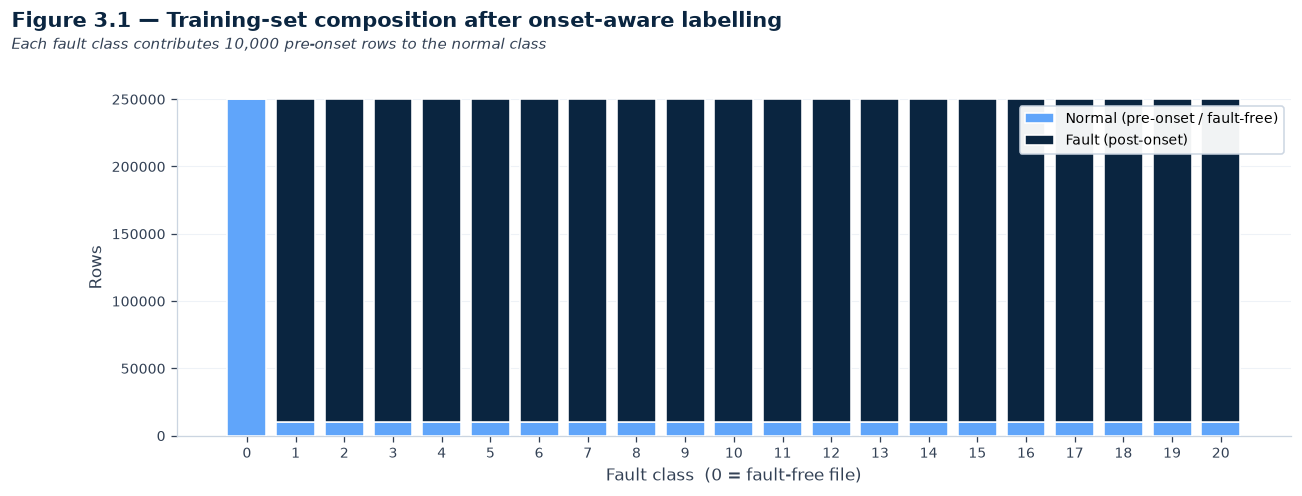

             normal   fault
faultNumber                
0            250000       0
1             10000  240000
2             10000  240000
3             10000  240000
4             10000  240000
5             10000  240000
6             10000  240000
7             10000  240000
8             10000  240000
9             10000  240000
10            10000  240000
11            10000  240000
12            10000  240000
13            10000  240000
14            10000  240000
15            10000  240000
16            10000  240000
17            10000  240000
18            10000  240000
19            10000  240000
20            10000  240000


In [3]:
# Figure 3.1 — label composition per fault class
comp = (train.groupby("faultNumber")["label"]
             .agg(normal=lambda s: int((s==0).sum()), fault=lambda s: int((s==1).sum())))
fig, ax = plt.subplots(figsize=(12.5, 3.8))
idx = comp.index.astype(int).astype(str)
ax.bar(idx, comp["normal"], color=SKY, edgecolor="white", zorder=3, label="Normal (pre-onset / fault-free)")
ax.bar(idx, comp["fault"], bottom=comp["normal"], color=NAVY, edgecolor="white", zorder=3, label="Fault (post-onset)")
ax.set_xlabel("Fault class  (0 = fault-free file)"); ax.set_ylabel("Rows"); ax.set_axisbelow(True)
ax.legend(fontsize=9, loc="upper right")
style_fig(fig, "Figure 3.1 \u2014 Training-set composition after onset-aware labelling",
          f"Each fault class contributes {CFG.ONSET_TRAIN*500:,} pre-onset rows to the normal class")
save_show(fig, "f3_1_composition")
print(comp.to_string())

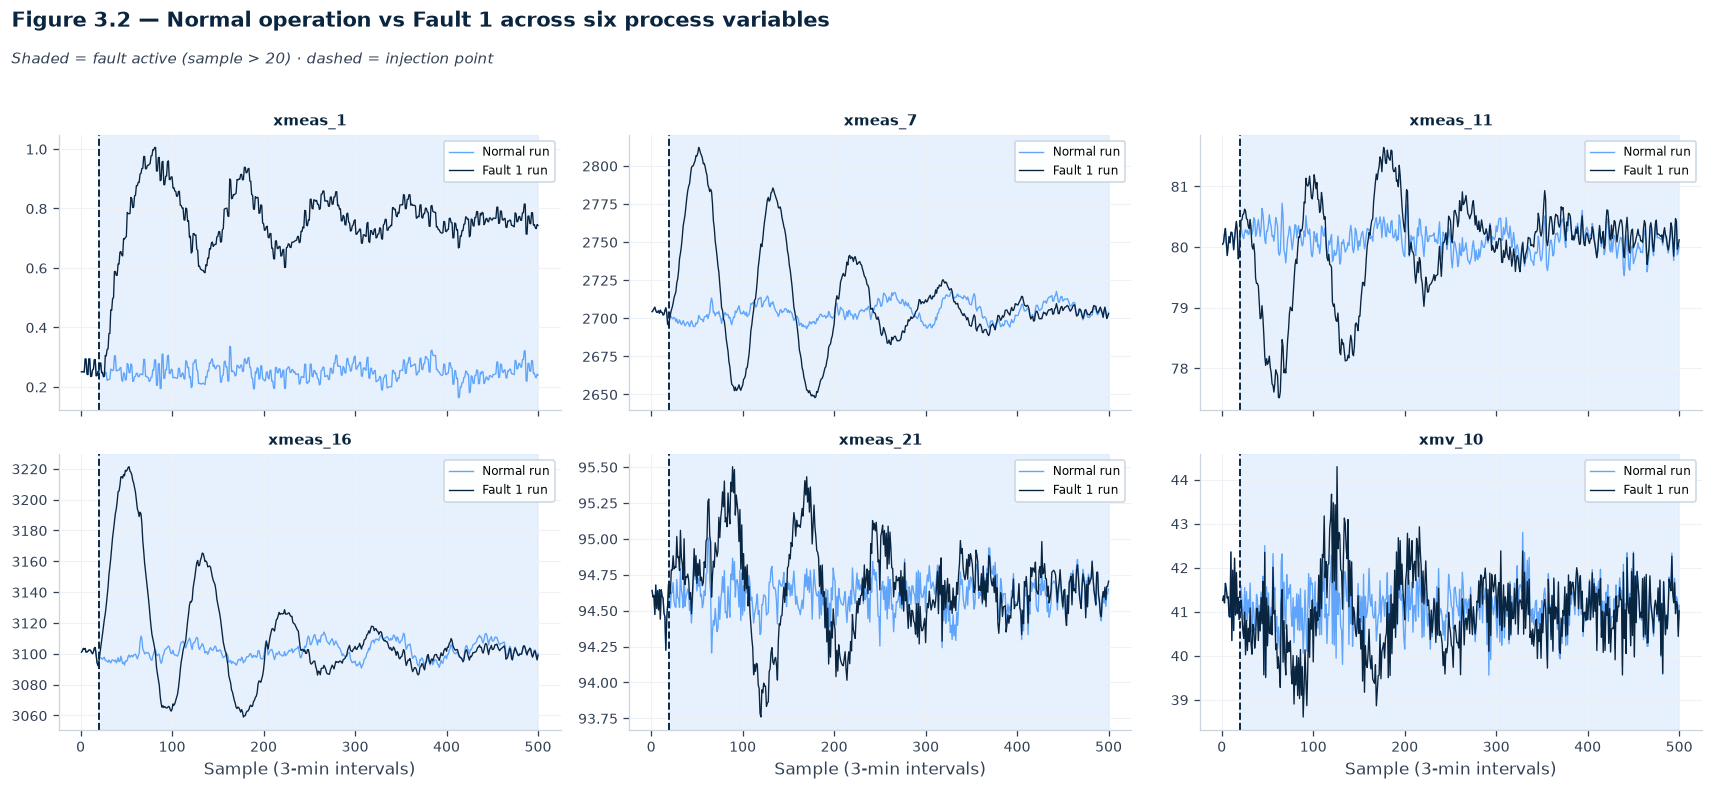

In [4]:
# Figure 3.2 — one faulty run vs one normal run
SENSORS, FAULT = ["xmeas_1","xmeas_7","xmeas_11","xmeas_16","xmeas_21","xmv_10"], 1
run_n = train[train.runKey == "0_1"].sort_values("sample")
run_f = train[train.runKey == f"{FAULT}_1"].sort_values("sample")
fig, axes = plt.subplots(2, 3, figsize=(15, 6.4), sharex=True)
for ax, s in zip(axes.ravel(), SENSORS):
    ax.axvspan(CFG.ONSET_TRAIN, run_f["sample"].max(), color=ICE, alpha=0.65, zorder=0)
    ax.plot(run_n["sample"], run_n[s], color=SKY,  lw=0.85, label="Normal run")
    ax.plot(run_f["sample"], run_f[s], color=NAVY, lw=0.85, label=f"Fault {FAULT} run")
    ax.axvline(CFG.ONSET_TRAIN, color=NAVY, ls="--", lw=1.2)
    ax.set_title(s, fontsize=9.5); ax.legend(fontsize=7.5); ax.set_axisbelow(True)
for ax in axes[1]: ax.set_xlabel("Sample (3-min intervals)")
style_fig(fig, f"Figure 3.2 \u2014 Normal operation vs Fault {FAULT} across six process variables",
          f"Shaded = fault active (sample > {CFG.ONSET_TRAIN}) \u00b7 dashed = injection point")
plt.tight_layout(rect=[0,0,1,0.95]); save_show(fig, "f3_2_signals")

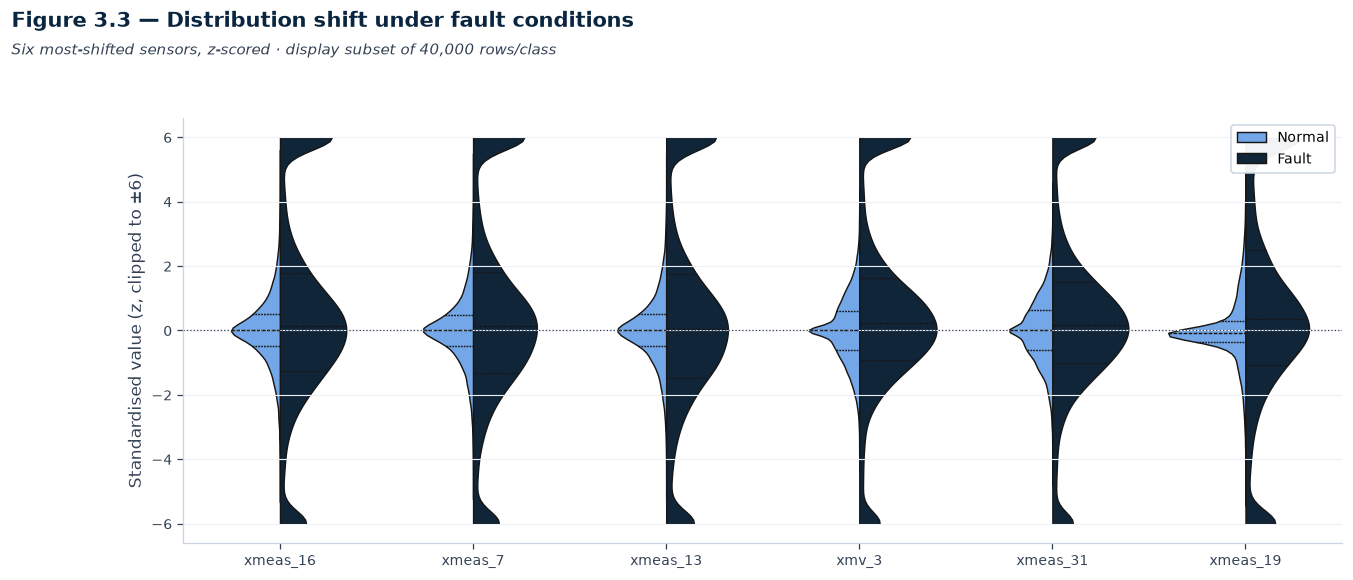

Largest normalised mean shifts (σ):
xmeas_16    3.95
xmeas_7     3.23
xmeas_13    2.94
xmv_3       2.26
xmeas_31    2.02
xmeas_19    2.02


In [5]:
# Figure 3.3 — distribution shift, z-scored so all sensors share one axis
DISPLAY_N = 40_000
sn = train[train.label==0].sample(DISPLAY_N, random_state=CFG.SEED)
sf = train[train.label==1].sample(DISPLAY_N, random_state=CFG.SEED)
mu, sd = sn[FEATURES].mean(), sn[FEATURES].std() + 1e-9
shift = ((sf[FEATURES].mean() - mu).abs() / sd).nlargest(6)
rows = []
for col in shift.index:
    rows.append(pd.DataFrame({"z": (sn[col]-mu[col])/sd[col], "sensor": col, "state": "Normal"}))
    rows.append(pd.DataFrame({"z": (sf[col]-mu[col])/sd[col], "sensor": col, "state": "Fault"}))
melt = pd.concat(rows, ignore_index=True); melt["z"] = melt["z"].clip(-6, 6)
fig, ax = plt.subplots(figsize=(13, 4.8))
sns.violinplot(data=melt, x="sensor", y="z", hue="state", split=True,
               palette=[SKY, NAVY], inner="quart", ax=ax, cut=0, linewidth=0.9)
ax.axhline(0, color=SLATE, lw=0.8, ls=":")
ax.set_xlabel(""); ax.set_ylabel("Standardised value (z, clipped to \u00b16)")
ax.legend(title="", fontsize=9, loc="upper right")
style_fig(fig, "Figure 3.3 \u2014 Distribution shift under fault conditions",
          f"Six most-shifted sensors, z-scored \u00b7 display subset of {DISPLAY_N:,} rows/class")
save_show(fig, "f3_3_distributions")
print("Largest normalised mean shifts (\u03c3):"); print(shift.round(2).to_string())

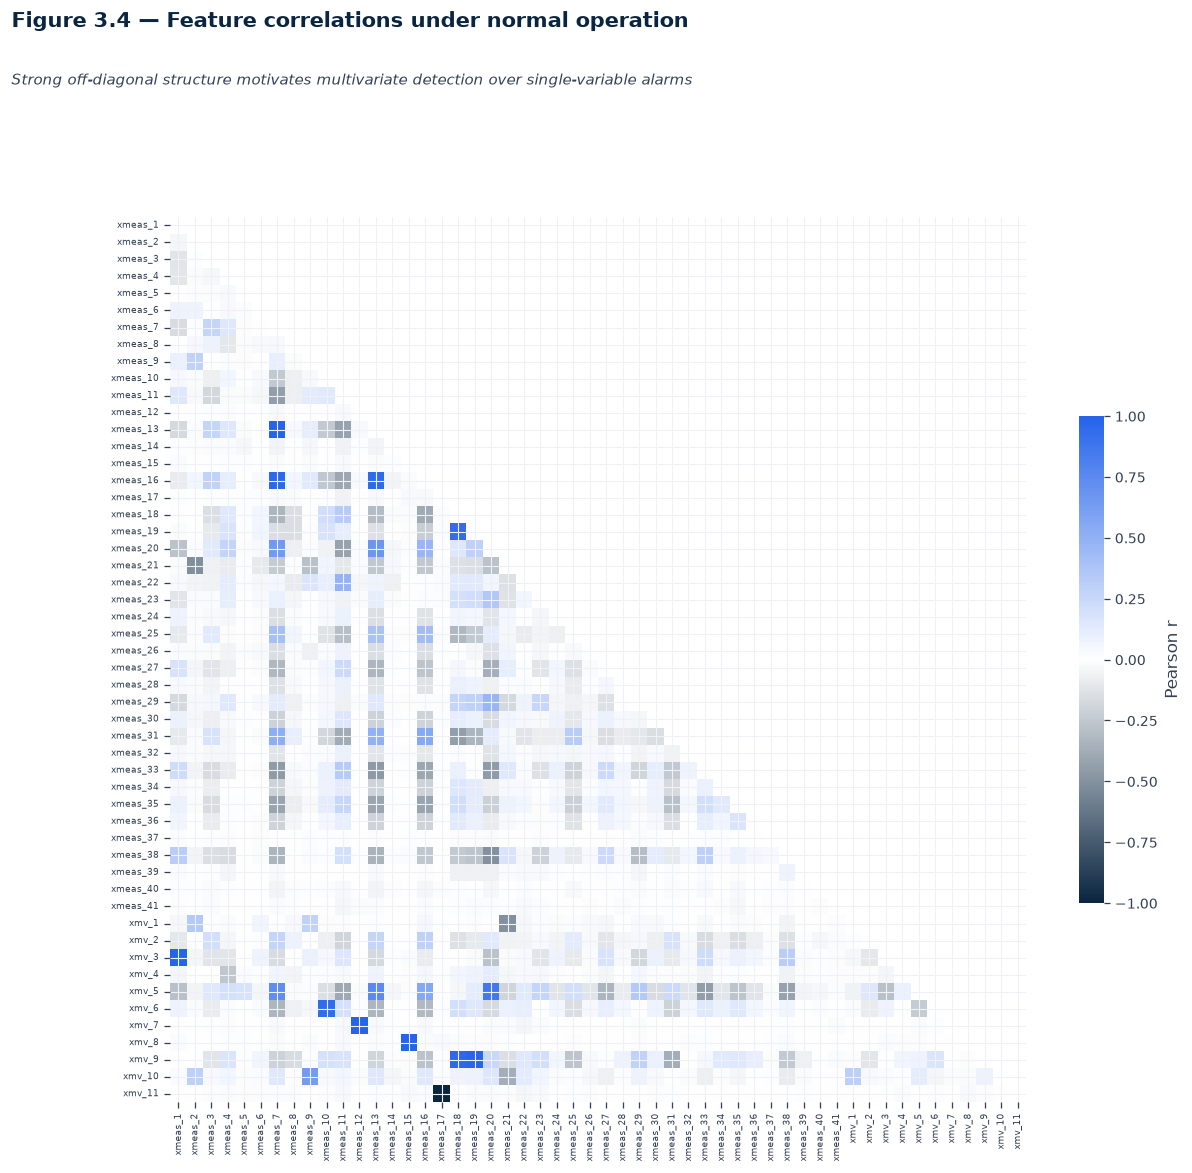

In [6]:
# Figure 3.4 — correlation structure
corr = train[train.label==0][FEATURES].sample(30_000, random_state=CFG.SEED).corr()
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, mask=np.triu(np.ones_like(corr, dtype=bool)), cmap=BLUES_DIV,
            center=0, vmin=-1, vmax=1, cbar_kws={"shrink":0.55,"label":"Pearson r"}, ax=ax)
ax.tick_params(labelsize=5.5)
style_fig(fig, "Figure 3.4 \u2014 Feature correlations under normal operation",
          "Strong off-diagonal structure motivates multivariate detection over single-variable alarms")
save_show(fig, "f3_4_correlation")

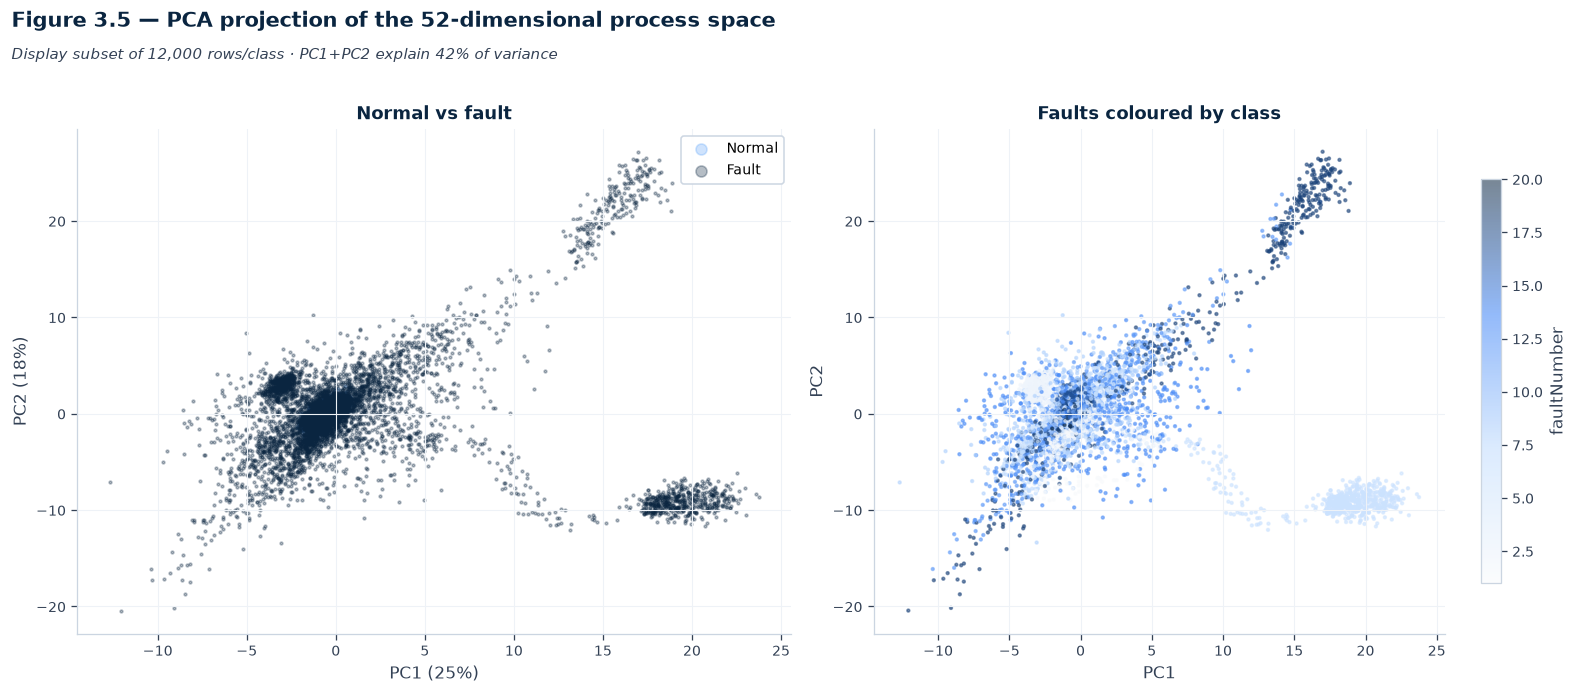

In [7]:
# Figure 3.5 — PCA projection
DN = 12_000
pn = train[train.label==0].sample(DN, random_state=CFG.SEED)
pf_ = train[train.label==1].sample(DN, random_state=CFG.SEED)
Z = StandardScaler().fit_transform(pd.concat([pn[FEATURES], pf_[FEATURES]], ignore_index=True))
pca = PCA(n_components=2, random_state=CFG.SEED); proj = pca.fit_transform(Z)
fig, axes = plt.subplots(1, 2, figsize=(14, 5.6))
axes[0].scatter(proj[:DN,0], proj[:DN,1], s=3, alpha=.30, color=SKY,  label="Normal", rasterized=True)
axes[0].scatter(proj[DN:,0], proj[DN:,1], s=3, alpha=.30, color=NAVY, label="Fault",  rasterized=True)
axes[0].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.0%})")
axes[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.0%})")
axes[0].set_title("Normal vs fault"); axes[0].legend(markerscale=4, fontsize=9)
sc = axes[1].scatter(proj[DN:,0], proj[DN:,1], s=3, alpha=.55,
                     c=pf_["faultNumber"].values, cmap=BLUES_SEQ, rasterized=True)
axes[1].set_title("Faults coloured by class"); axes[1].set_xlabel("PC1"); axes[1].set_ylabel("PC2")
plt.colorbar(sc, ax=axes[1], label="faultNumber", shrink=0.8)
style_fig(fig, "Figure 3.5 \u2014 PCA projection of the 52-dimensional process space",
          f"Display subset of {DN:,} rows/class \u00b7 PC1+PC2 explain "
          f"{pca.explained_variance_ratio_[:2].sum():.0%} of variance")
plt.tight_layout(rect=[0,0,1,0.95]); save_show(fig, "f3_5_pca")

## 4 · Preprocessing & Scaling

`StandardScaler` is fitted on the **training split only**. The ~10 million test rows are scaled and
predicted in chunks so memory stays bounded.

In [8]:
scaler = StandardScaler().fit(train[FEATURES].values)
y_tr = train["label"].values.astype(np.int8)
y_te = test["label"].values.astype(np.int8)
f_te = test["faultNumber"].values.astype(np.int16)

def scaled_chunks(df, chunk=CFG.CHUNK):
    for i in range(0, len(df), chunk):
        yield scaler.transform(df[FEATURES].values[i:i+chunk]).astype("float32")

def predict_chunked(df, fn, dtype="float32", chunk=CFG.CHUNK):
    out = []
    for blk in scaled_chunks(df, chunk):
        out.append(np.asarray(fn(blk), dtype=dtype)); del blk
    return np.concatenate(out)

def compute_metrics(y_true, y_pred, scores):
    return {"Precision": precision_score(y_true, y_pred, zero_division=0),
            "Recall":    recall_score(y_true, y_pred, zero_division=0),
            "F1":        f1_score(y_true, y_pred, zero_division=0),
            "ROC-AUC":   roc_auc_score(y_true, scores),
            "Bal. Acc.": balanced_accuracy_score(y_true, y_pred)}

def dcs_metrics(y_true, y_pred, scores):
    """Operational view. Counts are cast to float FIRST: numpy int64 overflows
    when four ~1e7 counts are multiplied, which silently yields complex MCC values."""
    tn, fp, fn, tp = [float(v) for v in confusion_matrix(y_true, y_pred).ravel()]
    den = ((tp+fp)*(tp+fn)*(tn+fp)*(tn+fn))**0.5
    return {"Detection rate": tp/(tp+fn), "False-alarm rate": fp/(fp+tn),
            "Miss rate": fn/(tp+fn), "MCC": (tp*tn-fp*fn)/den if den else 0.0,
            "ROC-AUC": roc_auc_score(y_true, scores)}

def detection_at_far(y_true, score, target_far):
    """Threshold the score so exactly target_far of NORMAL rows alarm; return detection rate."""
    thr = np.quantile(score[y_true == 0], 1 - target_far)
    pred = score > thr
    return thr, pred[y_true == 1].mean(), pred[y_true == 0].mean()

X_tr_normal = scaler.transform(train.loc[train.label==0, FEATURES].values).astype("float32")
print(f"Scaler fitted on {len(train):,} training rows (test files never seen).")
print(f"Normal-only training matrix: {X_tr_normal.shape}")
print(f"Test set: {len(test):,} rows in {int(np.ceil(len(test)/CFG.CHUNK))} chunks.")

Scaler fitted on 5,250,000 training rows (test files never seen).
Normal-only training matrix: (450000, 52)
Test set: 10,080,000 rows in 21 chunks.


## 5 · Baseline — Static 3σ Threshold *(conventional DCS alarm — RQ1 reference)*

A sample alarms if **any** of the 52 standardised variables exceeds |z| > 3. No multivariate
reasoning, no learning — the incumbent that RQ1 asks the ML models to beat.

In [9]:
thr_pred   = predict_chunked(test, lambda b: (np.abs(b) > CFG.THRESH_SIGMA).any(axis=1), dtype="int8")
thr_scores = predict_chunked(test, lambda b: np.abs(b).max(axis=1))
thr_metrics = compute_metrics(y_te, thr_pred, thr_scores)
print("=== Static 3\u03c3 threshold \u2014 conventional DCS alarm ===")
print(classification_report(y_te, thr_pred, target_names=["Normal","Fault"], digits=3))
print({k: round(v,3) for k,v in thr_metrics.items()})

=== Static 3σ threshold — conventional DCS alarm ===
              precision    recall  f1-score   support

      Normal      0.273     0.990     0.428   2080000
       Fault      0.992     0.314     0.478   8000000

    accuracy                          0.454  10080000
   macro avg      0.633     0.652     0.453  10080000
weighted avg      0.844     0.454     0.467  10080000

{'Precision': 0.992, 'Recall': 0.314, 'F1': 0.478, 'ROC-AUC': 0.72, 'Bal. Acc.': 0.652}


## 6 · Model 1 — Isolation Forest *(unsupervised)*

Fitted on normal training data only; never sees a fault label.

**Threshold calibration.** `IsolationForest.predict()` uses an internal `contamination` cut-off that
assumes a fault rate the analyst rarely knows in advance; in testing it produced a near-useless
operating point (recall ≈ 0.01). The threshold is instead set at the **95th percentile of anomaly
score on normal training data** — the same rule used for the autoencoder in §8, so the two
unsupervised detectors are directly comparable.

In [10]:
t0 = time.time()
iso = IsolationForest(n_estimators=300, max_samples=50_000, contamination="auto",
                      random_state=CFG.SEED, n_jobs=-1)
iso.fit(X_tr_normal); iso_time = time.time() - t0

iso_train_scores = -iso.score_samples(X_tr_normal)
ISO_THRESHOLD    = np.percentile(iso_train_scores, CFG.AE_PCTL)
iso_scores = predict_chunked(test, lambda b: -iso.score_samples(b))
iso_pred   = (iso_scores > ISO_THRESHOLD).astype("int8")
iso_metrics = compute_metrics(y_te, iso_pred, iso_scores)

print(f"Trained on {len(X_tr_normal):,} normal rows in {iso_time:.0f}s")
print(f"Alarm threshold = {ISO_THRESHOLD:.4f}  (P{CFG.AE_PCTL} of normal training score)")
print(classification_report(y_te, iso_pred, target_names=["Normal","Fault"], digits=3))

Trained on 450,000 normal rows in 3s
Alarm threshold = 0.4218  (P95 of normal training score)
              precision    recall  f1-score   support

      Normal      0.383     0.944     0.545   2080000
       Fault      0.977     0.605     0.747   8000000

    accuracy                          0.675  10080000
   macro avg      0.680     0.775     0.646  10080000
weighted avg      0.854     0.675     0.705  10080000



## 7 · Model 2 — Random Forest *(supervised)*

The performance ceiling when labelled fault history exists, and the model SHAP is applied to in
§12. `class_weight="balanced"` compensates for the ~1:10.7 normal/fault ratio.

> **Runtime:** 100 trees on 5.25 million rows — roughly **10–20 minutes** on an Apple M1.

In [11]:
t0 = time.time()
rf = RandomForestClassifier(n_estimators=CFG.RF_TREES, max_depth=CFG.RF_DEPTH,
                            class_weight="balanced", min_samples_leaf=5,
                            random_state=CFG.SEED, n_jobs=-1)
X_tr_all = scaler.transform(train[FEATURES].values).astype("float32")
rf.fit(X_tr_all, y_tr); rf_time = time.time() - t0
del X_tr_all; gc.collect()

rf_proba = predict_chunked(test, lambda b: rf.predict_proba(b)[:, 1])
rf_pred  = (rf_proba >= 0.5).astype("int8")
rf_metrics = compute_metrics(y_te, rf_pred, rf_proba)
print(f"Trained on {len(train):,} rows in {rf_time:.0f}s")
print(classification_report(y_te, rf_pred, target_names=["Normal","Fault"], digits=3))

Trained on 5,250,000 rows in 886s
              precision    recall  f1-score   support

      Normal      0.519     0.971     0.676   2080000
       Fault      0.990     0.766     0.864   8000000

    accuracy                          0.808  10080000
   macro avg      0.755     0.869     0.770  10080000
weighted avg      0.893     0.808     0.825  10080000



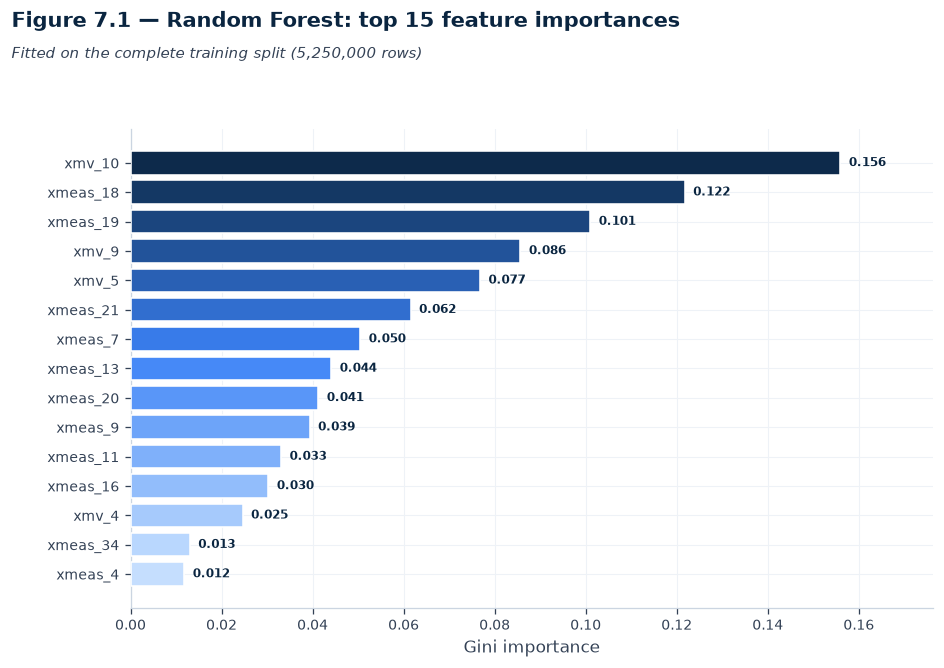

In [12]:
imp = pd.Series(rf.feature_importances_, index=FEATURES).nlargest(15).sort_values()
fig, ax = plt.subplots(figsize=(9, 5.4))
grad = [BLUES_SEQ(0.30 + 0.68*i/(len(imp)-1)) for i in range(len(imp))]
ax.barh(imp.index, imp.values, color=grad, edgecolor="white", zorder=3)
for i, v in enumerate(imp.values):
    ax.text(v + imp.max()*0.012, i, f"{v:.3f}", va="center", fontsize=7.8, color=NAVY, fontweight="bold")
ax.set_xlabel("Gini importance"); ax.set_xlim(0, imp.max()*1.13); ax.set_axisbelow(True)
style_fig(fig, "Figure 7.1 \u2014 Random Forest: top 15 feature importances",
          f"Fitted on the complete training split ({len(train):,} rows)")
save_show(fig, "f7_1_rf_importance")

## 8 · Model 3 — LSTM Autoencoder *(semi-supervised, temporal)*

Trained to reconstruct **windows of normal operation only**; faulty windows reconstruct poorly, so
reconstruction error becomes the anomaly score.

Three correctness requirements:

1. **Windows never cross a run boundary** — each is 10 consecutive samples from one `runKey`.
2. **Transition windows are discarded** — a window straddling the injection point is neither
   cleanly normal nor cleanly faulty.
3. **Validation uses held-out runs, not a positional slice.** Keras `validation_split` takes the
   last N% of samples by position, which would cut the boundary run in half across fit and
   validation. Entire fault-free runs are reserved instead.

In [13]:
def build_windows(df, w, batch_runs=CFG.RUN_BATCH, scale=True, drop_transition=True):
    """Yield (Xw, yw, fw) batches built run-by-run in true chronological order."""
    keys = df["runKey"].unique()
    for i in range(0, len(keys), batch_runs):
        Xs, ys, fs = [], [], []
        for rk in keys[i:i+batch_runs]:
            g = df[df.runKey == rk].sort_values("sample")
            n = len(g) // w
            if n == 0: continue
            v = g[FEATURES].values[:n*w].astype("float32")
            if scale: v = scaler.transform(v).astype("float32")
            lab = g["label"].values[:n*w].reshape(n, w)
            keep = (lab.min(axis=1) == lab.max(axis=1)) if drop_transition else np.ones(n, bool)
            if not keep.any(): continue
            Xs.append(v.reshape(n, w, len(FEATURES))[keep])
            ys.append(lab.max(axis=1)[keep].astype("int8"))
            fs.append(np.full(int(keep.sum()), int(g["faultNumber"].iloc[0]), dtype="int16"))
        if Xs:
            yield np.concatenate(Xs), np.concatenate(ys), np.concatenate(fs)

# ── run-level fit / validation split over fault-free TRAINING runs ──
ff_runs = train[(train.label == 0) & (train.faultNumber == 0)]
ff_run_keys = ff_runs["runKey"].unique().copy()
rng_v = np.random.RandomState(CFG.SEED); rng_v.shuffle(ff_run_keys)
n_val = max(int(len(ff_run_keys) * 0.10), 1)
val_runs_ae, fit_runs_ae = ff_run_keys[:n_val], ff_run_keys[n_val:]
assert not (set(fit_runs_ae) & set(val_runs_ae)), "fit/val run overlap"

Xw_fit = np.concatenate([b[0] for b in
            build_windows(ff_runs[ff_runs.runKey.isin(fit_runs_ae)], CFG.WINDOW)])
Xw_val = np.concatenate([b[0] for b in
            build_windows(ff_runs[ff_runs.runKey.isin(val_runs_ae)], CFG.WINDOW)])
print(f"Fit runs {len(fit_runs_ae)} \u2192 {Xw_fit.shape}")
print(f"Val runs {len(val_runs_ae)} \u2192 {Xw_val.shape}   (entirely separate simulations)")
assert len(Xw_fit) > 15_000, "Too few training windows \u2014 check the fault-free training file."

# ── test windows: streamed so ~1M windows never sit in memory at once ──
def stream_test_windows(model=None, w=CFG.WINDOW):
    ys, fs, errs = [], [], []
    for Xw, yw, fw in build_windows(test, w):
        ys.append(yw); fs.append(fw)
        if model is not None:
            errs.append(np.mean((Xw - model.predict(Xw, verbose=0))**2, axis=(1,2)).astype("float32"))
        del Xw
    return (np.concatenate(ys), np.concatenate(fs),
            np.concatenate(errs) if errs else None)

yw_te, fw_te, _ = stream_test_windows(None)
print(f"Test windows: {len(yw_te):,} \u00b7 Normal: {int((yw_te==0).sum()):,} "
      f"\u00b7 Fault: {int((yw_te==1).sum()):,}")
assert (yw_te==0).sum() > 50_000, "Too few normal test windows \u2014 check onset labelling."
print("Run-preserving, unanimously-labelled windows \u2014 class balance realistic.")

Fit runs 450 → (22500, 10, 52)
Val runs 50 → (2500, 10, 52)   (entirely separate simulations)
Test windows: 1,008,000 · Normal: 208,000 · Fault: 800,000
Run-preserving, unanimously-labelled windows — class balance realistic.


In [14]:
def build_ae(window, n_feat, units):
    inp = layers.Input(shape=(window, n_feat))
    z   = layers.LSTM(units)(inp)
    z   = layers.RepeatVector(window)(z)
    z   = layers.LSTM(units, return_sequences=True)(z)
    out = layers.TimeDistributed(layers.Dense(n_feat))(z)
    m = Model(inp, out); m.compile(optimizer="adam", loss="mse")
    return m

lstm_ae = build_ae(CFG.WINDOW, len(FEATURES), CFG.LSTM_UNITS)
t0 = time.time()
hist = lstm_ae.fit(Xw_fit, Xw_fit,
                   validation_data=(Xw_val, Xw_val),
                   epochs=CFG.LSTM_EPOCHS, batch_size=CFG.LSTM_BATCH,
                   verbose=1, shuffle=True,
                   callbacks=[callbacks.EarlyStopping(monitor="val_loss", patience=CFG.LSTM_PATIENCE,
                                                      restore_best_weights=True),
                              callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                                                          patience=8, min_lr=1e-6),
                              callbacks.ModelCheckpoint(os.path.join(MODELS_DIR, "lstm_ae.keras"),
                                                        save_best_only=True)])
lstm_time = time.time() - t0
n_ep = len(hist.history["loss"])
print(f"\nTrained on {len(Xw_fit):,} windows in {lstm_time:.0f}s \u00b7 stopped at epoch {n_ep}")
print(f"best val_loss {min(hist.history['val_loss']):.5f}")
print("Converged \u2014 early stopping fired \u2713" if n_ep < CFG.LSTM_EPOCHS
      else "\u26a0 Hit the epoch ceiling \u2014 raise CFG.LSTM_EPOCHS and re-run this cell.")

Epoch 1/200
88/88 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - loss: 0.2267 - val_loss: 0.2071 - learning_rate: 0.0010
Epoch 2/200
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.1942 - val_loss: 0.1802 - learning_rate: 0.0010
Epoch 3/200
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.1709 - val_loss: 0.1661 - learning_rate: 0.0010
Epoch 4/200
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.1627 - val_loss: 0.1602 - learning_rate: 0.0010
Epoch 5/200
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.1569 - val_loss: 0.1551 - learning_rate: 0.0010
Epoch 6/200
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.1526 - val_loss: 0.1516 - learning_rate: 0.0010
Epoch 7/200
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.1492 - val_loss: 0.1485 - learning_rate: 0.0010
Epoch 8/200
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.1460 - val_loss: 0.1450 - learning_rate: 0.0010
Epoch 9/200
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.1429 - val_loss: 0.1423 - learning_rate: 0.0010
Epoch 10/2

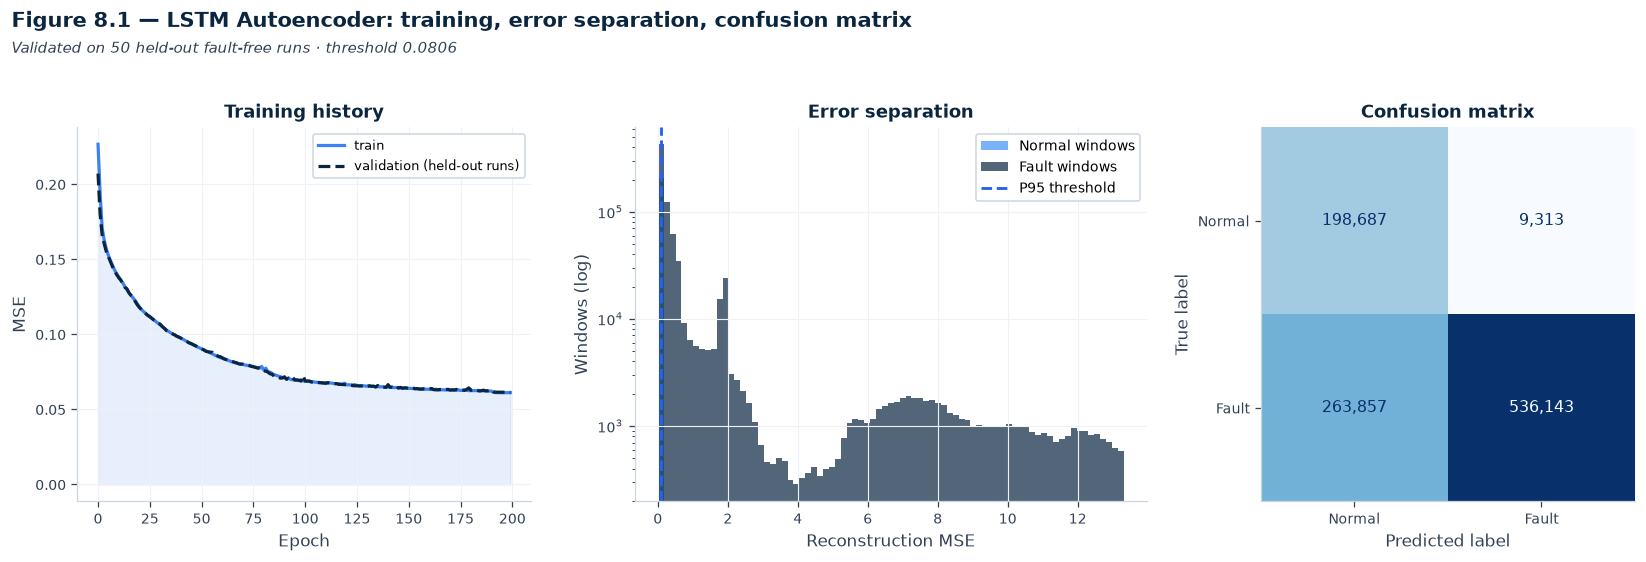

              precision    recall  f1-score   support

      Normal      0.430     0.955     0.593    208000
       Fault      0.983     0.670     0.797    800000

    accuracy                          0.729   1008000
   macro avg      0.706     0.813     0.695   1008000
weighted avg      0.869     0.729     0.755   1008000



In [15]:
# Threshold from HELD-OUT normal runs (never used to fit the weights)
err_val = np.mean((Xw_val - lstm_ae.predict(Xw_val, verbose=0))**2, axis=(1,2))
AE_THRESHOLD = np.percentile(err_val, CFG.AE_PCTL)
_, _, err_te = stream_test_windows(lstm_ae)
lstm_pred = (err_te > AE_THRESHOLD).astype("int8")
lstm_metrics = compute_metrics(yw_te, lstm_pred, err_te)

fig = plt.figure(figsize=(14.5, 4.5))
gs = gridspec.GridSpec(1, 3, width_ratios=[1.15, 1.3, 1])
ax0 = fig.add_subplot(gs[0])
ax0.plot(hist.history["loss"], color=STEEL, lw=2, label="train")
ax0.plot(hist.history["val_loss"], color=NAVY, lw=2, ls="--", label="validation (held-out runs)")
ax0.fill_between(range(len(hist.history["loss"])), hist.history["loss"], alpha=.12, color=STEEL)
ax0.set_xlabel("Epoch"); ax0.set_ylabel("MSE"); ax0.set_title("Training history"); ax0.legend(fontsize=8)

ax1 = fig.add_subplot(gs[1])
bins = np.linspace(0, np.percentile(err_te, 99.5), 80)
ax1.hist(err_te[yw_te==0], bins=bins, alpha=.85, color=SKY,  label="Normal windows")
ax1.hist(err_te[yw_te==1], bins=bins, alpha=.70, color=NAVY, label="Fault windows")
ax1.axvline(AE_THRESHOLD, color=ROYAL, ls="--", lw=1.8, label=f"P{CFG.AE_PCTL} threshold")
ax1.set_yscale("log"); ax1.legend(fontsize=8.5)
ax1.set_xlabel("Reconstruction MSE"); ax1.set_ylabel("Windows (log)"); ax1.set_title("Error separation")

ax2 = fig.add_subplot(gs[2])
ConfusionMatrixDisplay.from_predictions(yw_te, lstm_pred, display_labels=["Normal","Fault"],
                                        cmap="Blues", colorbar=False, ax=ax2, values_format=",")
ax2.set_title("Confusion matrix"); ax2.grid(False)
style_fig(fig, "Figure 8.1 \u2014 LSTM Autoencoder: training, error separation, confusion matrix",
          f"Validated on {len(val_runs_ae)} held-out fault-free runs \u00b7 threshold {AE_THRESHOLD:.4f}")
plt.tight_layout(rect=[0,0,1,0.93]); save_show(fig, "f8_1_lstm")
print(classification_report(yw_te, lstm_pred, target_names=["Normal","Fault"], digits=3))

## 9 · Comparative & Operational Evaluation *(RQ2)*

Two views. The classical view (Precision/Recall/F1) is reported for comparability with the
literature. The **operational view** — detection rate at a matched false-alarm budget — is the one
a control-room engineer actually uses, and the one that is not distorted by the fact that the test
set is 79% faults.

In [16]:
results = pd.DataFrame([thr_metrics, iso_metrics, rf_metrics, lstm_metrics],
                       index=MODEL_ORDER).round(3)
results.insert(0, "Paradigm", ["Rule-based","Unsupervised","Supervised","Semi-supervised"])
results.insert(1, "Train time (s)", [0, round(iso_time), round(rf_time), round(lstm_time)])
results.to_csv(os.path.join(RESULTS_DIR, "model_comparison.csv"))
results

,Paradigm,Train time (s),Precision,Recall,F1,ROC-AUC,Bal. Acc.
Threshold (3σ),Rule-based,0,0.992,0.314,0.478,0.720,0.652
Isolation Forest,Unsupervised,3,0.977,0.605,0.747,0.864,0.775
Random Forest,Supervised,886,0.990,0.766,0.864,0.919,0.869
LSTM Autoencoder,Semi-supervised,361,0.983,0.670,0.797,0.860,0.813


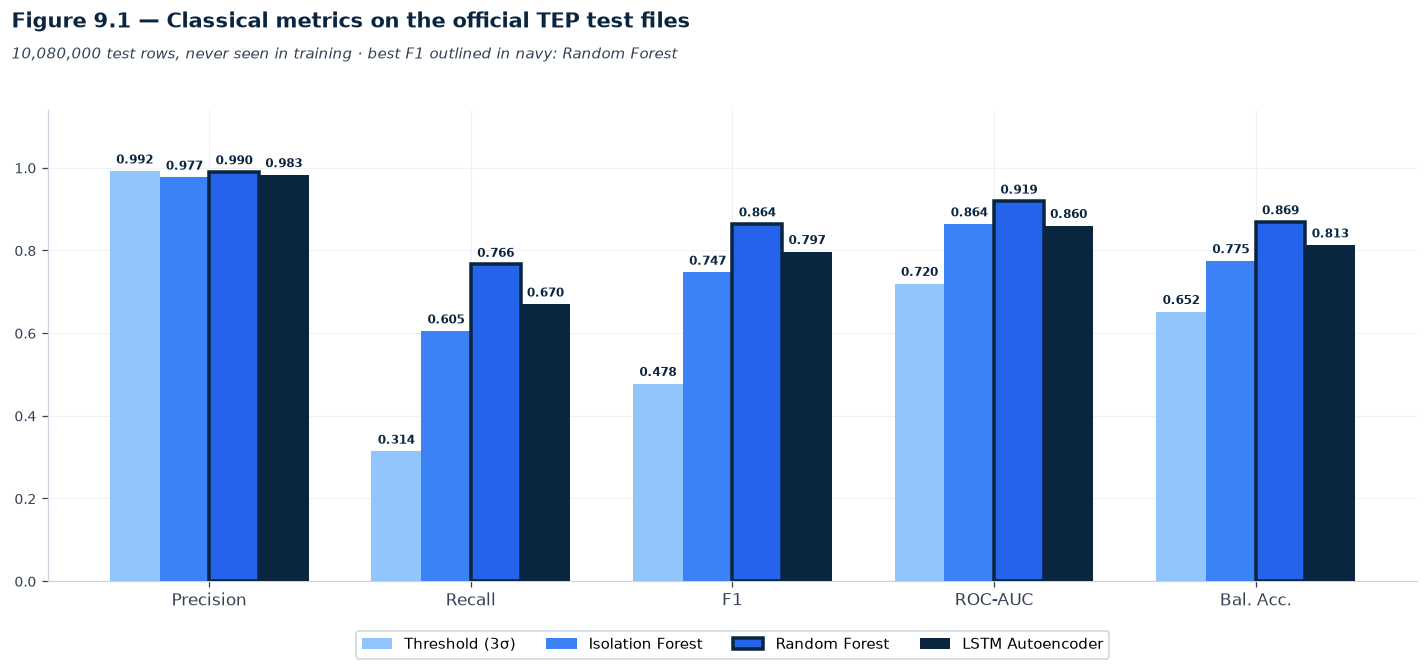

In [17]:
metrics_list = ["Precision","Recall","F1","ROC-AUC","Bal. Acc."]
x, w = np.arange(len(metrics_list)), 0.19
fig, ax = plt.subplots(figsize=(12.5, 5.4))
best = results["F1"].astype(float).idxmax()
for i, model in enumerate(MODEL_ORDER):
    vals = results.loc[model, metrics_list].astype(float).values
    bars = ax.bar(x + i*w, vals, w, label=model, color=MODEL_PALETTE[model],
                  edgecolor=NAVY, linewidth=2.2 if model == best else 0, zorder=3)
    ax.bar_label(bars, labels=[f"{v:.3f}" for v in vals], fontsize=7.4,
                 padding=3, color=NAVY, fontweight="bold")
ax.set_xticks(x + 1.5*w); ax.set_xticklabels(metrics_list, fontsize=10.5)
ax.set_ylim(0, 1.14); ax.set_axisbelow(True)
ax.legend(loc="upper center", bbox_to_anchor=(0.5,-0.09), ncol=4, fontsize=9.5)
style_fig(fig, "Figure 9.1 \u2014 Classical metrics on the official TEP test files",
          f"{len(test):,} test rows, never seen in training \u00b7 best F1 outlined in navy: {best}")
plt.tight_layout(rect=[0,0,1,0.94]); save_show(fig, "f9_1_comparison")

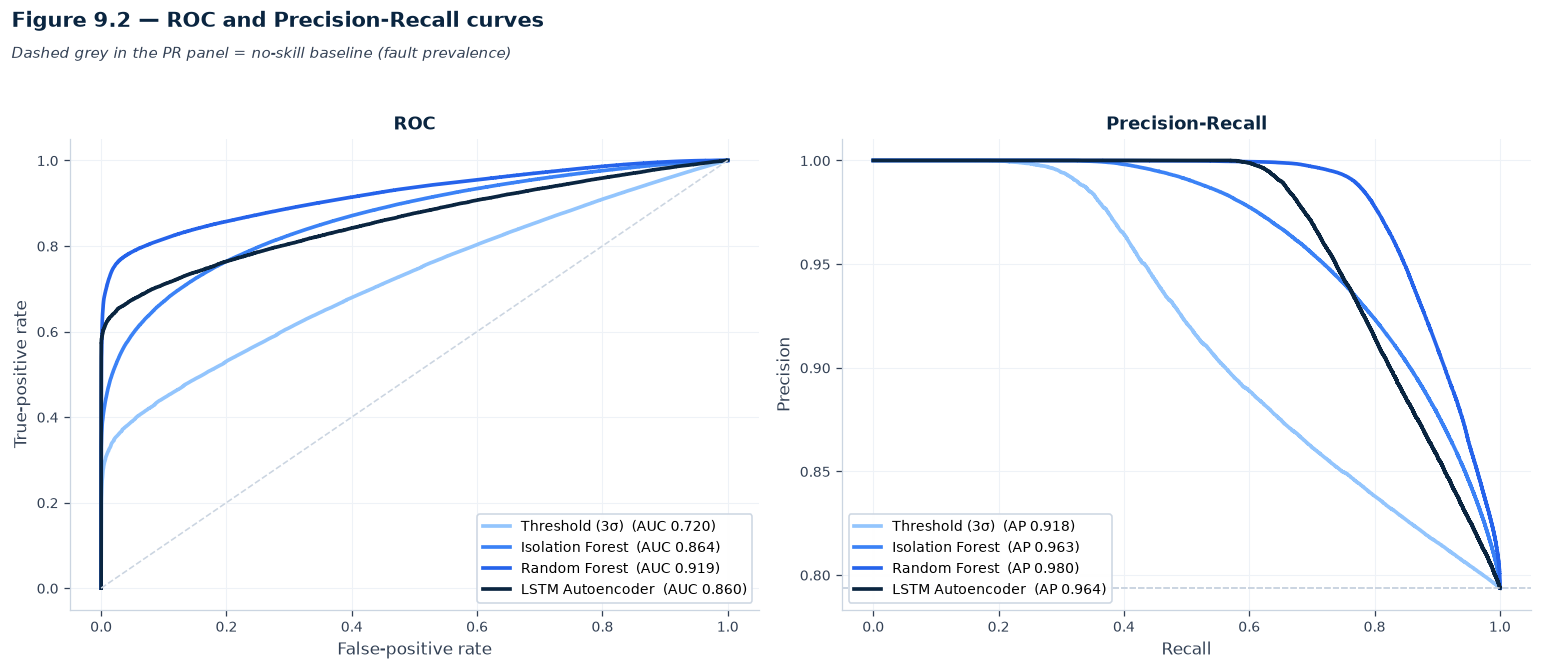

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.4))
curves = [("Threshold (3\u03c3)", y_te, thr_scores), ("Isolation Forest", y_te, iso_scores),
          ("Random Forest", y_te, rf_proba), ("LSTM Autoencoder", yw_te, err_te)]
for name, yt, sc in curves:
    fpr, tpr, _ = roc_curve(yt, sc)
    axes[0].plot(fpr, tpr, color=MODEL_PALETTE[name], lw=2.3,
                 label=f"{name}  (AUC {roc_auc_score(yt, sc):.3f})")
axes[0].plot([0,1],[0,1], color="#CBD5E1", ls="--", lw=1)
axes[0].set_xlabel("False-positive rate"); axes[0].set_ylabel("True-positive rate")
axes[0].set_title("ROC"); axes[0].legend(loc="lower right", fontsize=8.5)
for name, yt, sc in curves:
    prec, rec, _ = precision_recall_curve(yt, sc)
    axes[1].plot(rec, prec, color=MODEL_PALETTE[name], lw=2.3,
                 label=f"{name}  (AP {average_precision_score(yt, sc):.3f})")
    axes[1].axhline(np.mean(yt), color="#CBD5E1", ls="--", lw=1)
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall"); axes[1].legend(loc="lower left", fontsize=8.5)
style_fig(fig, "Figure 9.2 \u2014 ROC and Precision-Recall curves",
          "Dashed grey in the PR panel = no-skill baseline (fault prevalence)")
plt.tight_layout(rect=[0,0,1,0.93]); save_show(fig, "f9_2_roc_pr")

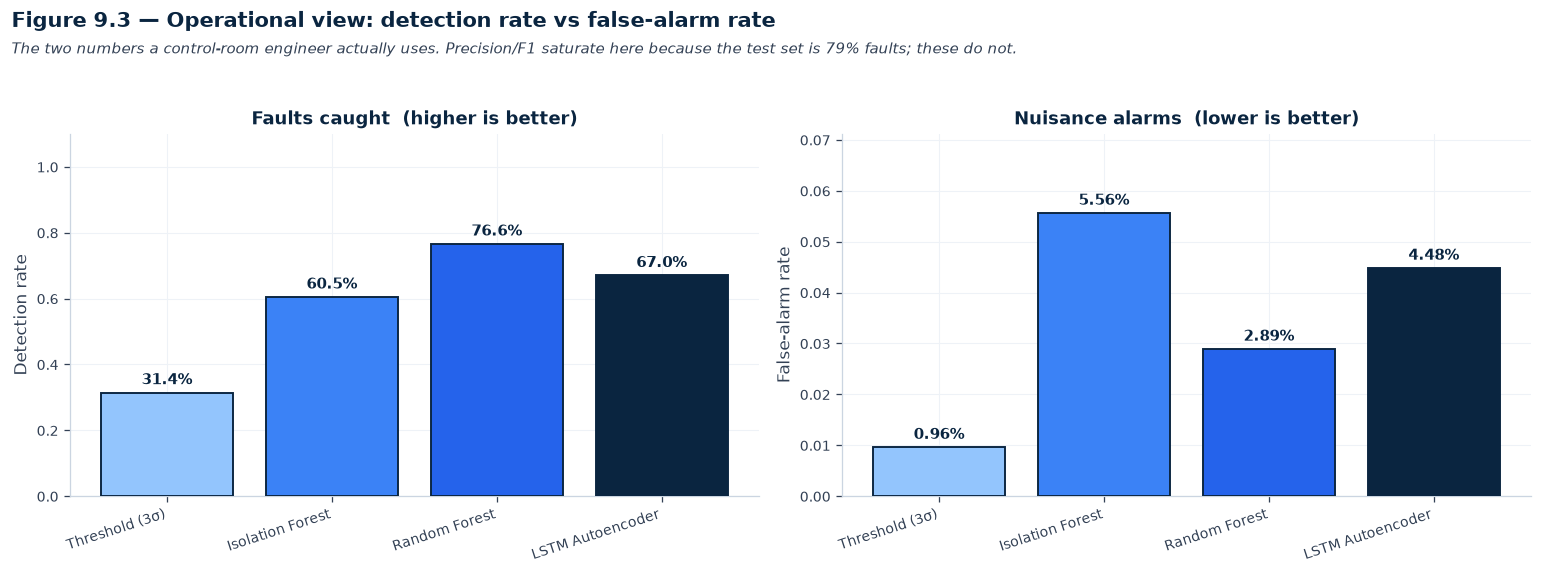

,Detection rate,False-alarm rate,Miss rate,MCC,ROC-AUC
Threshold (3σ),0.3145,0.0096,0.6855,0.2843,0.7197
Isolation Forest,0.6048,0.0556,0.3952,0.4445,0.8645
Random Forest,0.7659,0.0289,0.2341,0.6126,0.9190
LSTM Autoencoder,0.6702,0.0448,0.3298,0.5079,0.8596


In [19]:
# ── Operational view ──
ops = pd.DataFrame([dcs_metrics(y_te,  thr_pred,  thr_scores),
                    dcs_metrics(y_te,  iso_pred,  iso_scores),
                    dcs_metrics(y_te,  rf_pred,   rf_proba),
                    dcs_metrics(yw_te, lstm_pred, err_te)], index=MODEL_ORDER).round(4)
ops.to_csv(os.path.join(RESULTS_DIR, "operational_metrics.csv"))

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.6))
xs = np.arange(len(MODEL_ORDER)); cols = [MODEL_PALETTE[m] for m in MODEL_ORDER]
b1 = axes[0].bar(xs, ops["Detection rate"], color=cols, edgecolor=NAVY, lw=1.2, zorder=3)
axes[0].bar_label(b1, labels=[f"{v:.1%}" for v in ops["Detection rate"]],
                  fontsize=9.5, color=NAVY, fontweight="bold", padding=3)
axes[0].set_ylim(0, 1.1); axes[0].set_ylabel("Detection rate")
axes[0].set_title("Faults caught  (higher is better)")
b2 = axes[1].bar(xs, ops["False-alarm rate"], color=cols, edgecolor=NAVY, lw=1.2, zorder=3)
axes[1].bar_label(b2, labels=[f"{v:.2%}" for v in ops["False-alarm rate"]],
                  fontsize=9.5, color=NAVY, fontweight="bold", padding=3)
axes[1].set_ylim(0, float(ops["False-alarm rate"].max())*1.28)
axes[1].set_ylabel("False-alarm rate"); axes[1].set_title("Nuisance alarms  (lower is better)")
for ax in axes:
    ax.set_xticks(xs); ax.set_xticklabels(MODEL_ORDER, rotation=18, ha="right", fontsize=9)
    ax.set_axisbelow(True)
style_fig(fig, "Figure 9.3 \u2014 Operational view: detection rate vs false-alarm rate",
          "The two numbers a control-room engineer actually uses. Precision/F1 saturate here "
          "because the test set is 79% faults; these do not.")
plt.tight_layout(rect=[0,0,1,0.92]); save_show(fig, "f9_3_operational")
ops

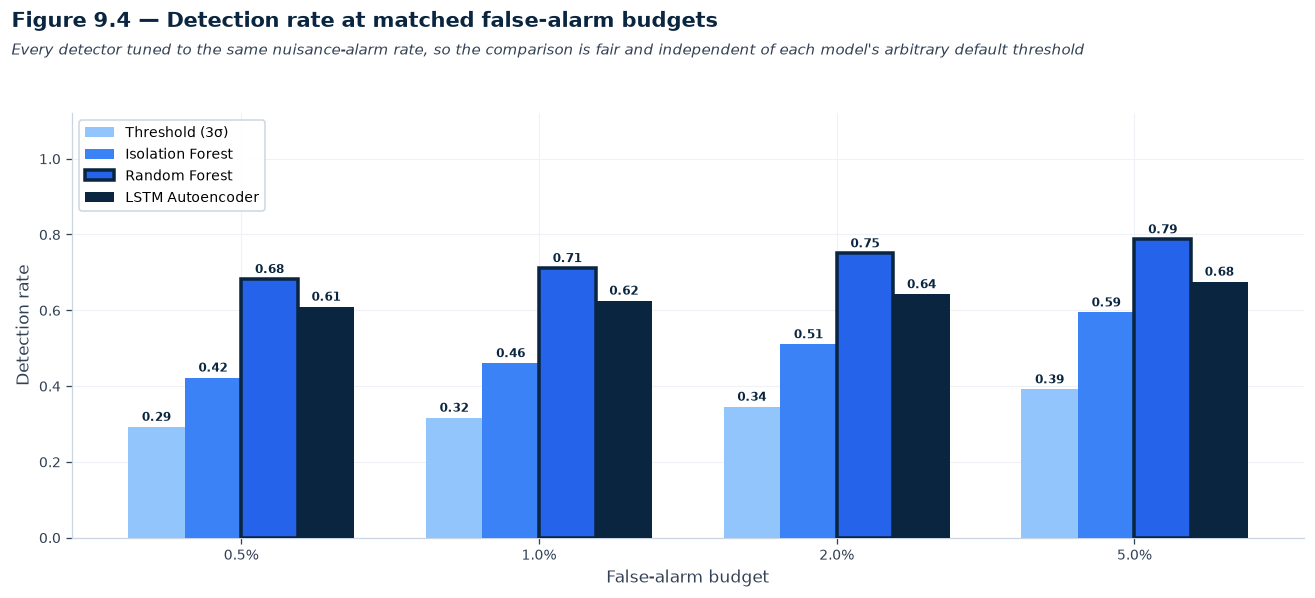

,Det @ 0.5% FAR,Det @ 1.0% FAR,Det @ 2.0% FAR,Det @ 5.0% FAR
Model,,,,
Threshold (3σ),0.292,0.316,0.345,0.391
Isolation Forest,0.422,0.460,0.510,0.594
Random Forest,0.682,0.711,0.750,0.787
LSTM Autoencoder,0.609,0.625,0.642,0.675


In [20]:
# ── Equal false-alarm budget comparison (headline result) ──
rows = []
for name, yt, sc in [("Threshold (3\u03c3)", y_te, thr_scores), ("Isolation Forest", y_te, iso_scores),
                     ("Random Forest", y_te, rf_proba),        ("LSTM Autoencoder", yw_te, err_te)]:
    r = {"Model": name}
    for f in CFG.FAR_BUDGETS:
        _, det, _ = detection_at_far(yt, sc, f)
        r[f"Det @ {f:.1%} FAR"] = round(float(det), 3)
    rows.append(r)
far_tbl = pd.DataFrame(rows).set_index("Model")
far_tbl.to_csv(os.path.join(RESULTS_DIR, "equal_far_comparison.csv"))

x, w = np.arange(len(CFG.FAR_BUDGETS)), 0.19
fig, ax = plt.subplots(figsize=(11.5, 4.8))
for i, name in enumerate(MODEL_ORDER):
    v = far_tbl.loc[name].values.astype(float)
    bars = ax.bar(x + i*w, v, w, label=name, color=MODEL_PALETTE[name], edgecolor=NAVY,
                  lw=2.2 if name == "Random Forest" else 0, zorder=3)
    ax.bar_label(bars, labels=[f"{q:.2f}" for q in v], fontsize=7.5,
                 color=NAVY, fontweight="bold", padding=2)
ax.set_xticks(x + 1.5*w); ax.set_xticklabels([f"{f:.1%}" for f in CFG.FAR_BUDGETS])
ax.set_xlabel("False-alarm budget"); ax.set_ylabel("Detection rate"); ax.set_ylim(0, 1.12)
ax.legend(loc="upper left", fontsize=9); ax.set_axisbelow(True)
style_fig(fig, "Figure 9.4 \u2014 Detection rate at matched false-alarm budgets",
          "Every detector tuned to the same nuisance-alarm rate, so the comparison is fair and "
          "independent of each model's arbitrary default threshold")
plt.tight_layout(rect=[0,0,1,0.92]); save_show(fig, "f9_4_equal_far")
far_tbl

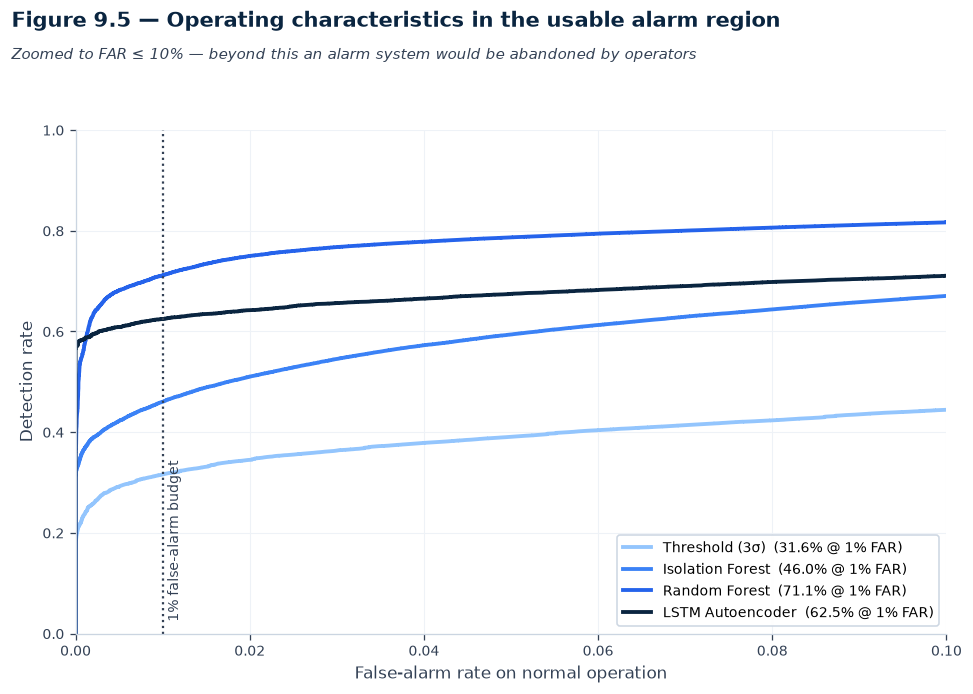

In [21]:
# ── Operating-characteristic curve, zoomed to the usable alarm region ──
fig, ax = plt.subplots(figsize=(8.5, 5.6))
for name, yt, sc in [("Threshold (3\u03c3)", y_te, thr_scores), ("Isolation Forest", y_te, iso_scores),
                     ("Random Forest", y_te, rf_proba),        ("LSTM Autoencoder", yw_te, err_te)]:
    fpr, tpr, _ = roc_curve(yt, sc)
    m = fpr <= 0.10
    ax.plot(fpr[m], tpr[m], color=MODEL_PALETTE[name], lw=2.4,
            label=f"{name}  ({np.interp(0.01, fpr, tpr):.1%} @ 1% FAR)")
ax.axvline(0.01, color=SLATE, ls=":", lw=1.4)
ax.text(0.0105, 0.03, "1% false-alarm budget", fontsize=8.5, color=SLATE, rotation=90)
ax.set_xlim(0, 0.10); ax.set_ylim(0, 1)
ax.set_xlabel("False-alarm rate on normal operation"); ax.set_ylabel("Detection rate")
ax.legend(loc="lower right", fontsize=9); ax.set_axisbelow(True)
style_fig(fig, "Figure 9.5 \u2014 Operating characteristics in the usable alarm region",
          "Zoomed to FAR \u2264 10% \u2014 beyond this an alarm system would be abandoned by operators")
plt.tight_layout(rect=[0,0,1,0.92]); save_show(fig, "f9_5_far_curve")

In [22]:
# ── Per-fault F1 + paired significance testing ──
def per_fault_f1(y_true, y_pred, fault_ids):
    base = fault_ids == 0; rows = {}
    for f in range(1, 21):
        m = base | (fault_ids == f)
        if (fault_ids[m] == f).any():
            rows[f] = f1_score(y_true[m], y_pred[m], zero_division=0)
    return pd.Series(rows)

pf = pd.DataFrame({
    "Threshold (3\u03c3)": per_fault_f1(y_te,  thr_pred,  f_te),
    "Isolation Forest":  per_fault_f1(y_te,  iso_pred,  f_te),
    "Random Forest":     per_fault_f1(y_te,  rf_pred,   f_te),
    "LSTM Autoencoder":  per_fault_f1(yw_te, lstm_pred, fw_te)})
pf.to_csv(os.path.join(RESULTS_DIR, "per_fault_f1.csv"))

pairs = [("Random Forest","Isolation Forest"), ("Random Forest","LSTM Autoencoder"),
         ("Random Forest","Threshold (3\u03c3)"), ("LSTM Autoencoder","Isolation Forest"),
         ("LSTM Autoencoder","Threshold (3\u03c3)"), ("Isolation Forest","Threshold (3\u03c3)")]
stat_rows = []
for a, b in pairs:
    s, p = stats.wilcoxon(pf[a], pf[b])
    stat_rows.append({"Comparison": f"{a} vs {b}",
                      "median \u0394F1": round(float((pf[a]-pf[b]).median()), 3),
                      "W": s, "p-value": p, "Significant (\u03b1=0.05)": "Yes" if p < 0.05 else "No"})
stat_df = pd.DataFrame(stat_rows).round(4)
stat_df.to_csv(os.path.join(RESULTS_DIR, "wilcoxon_tests.csv"), index=False)
stat_df

,Comparison,median ΔF1,W,p-value,Significant (α=0.05)
0,Random Forest vs Isolation Forest,0.069,27.0,0.0023,Yes
1,Random Forest vs LSTM Autoencoder,0.007,32.0,0.0049,Yes
2,Random Forest vs Threshold (3σ),0.348,3.0,0.0000,Yes
3,LSTM Autoencoder vs Isolation Forest,0.024,85.0,0.4749,No
4,LSTM Autoencoder vs Threshold (3σ),0.288,3.0,0.0000,Yes
5,Isolation Forest vs Threshold (3σ),0.228,10.0,0.0001,Yes


## 10 · Per-Fault Analysis & Detection Latency

Latency is measured on the **testing** runs, where the fault is injected at sample 160. Runs never
flagged are reported separately, so the detection *rate* is visible alongside the speed.

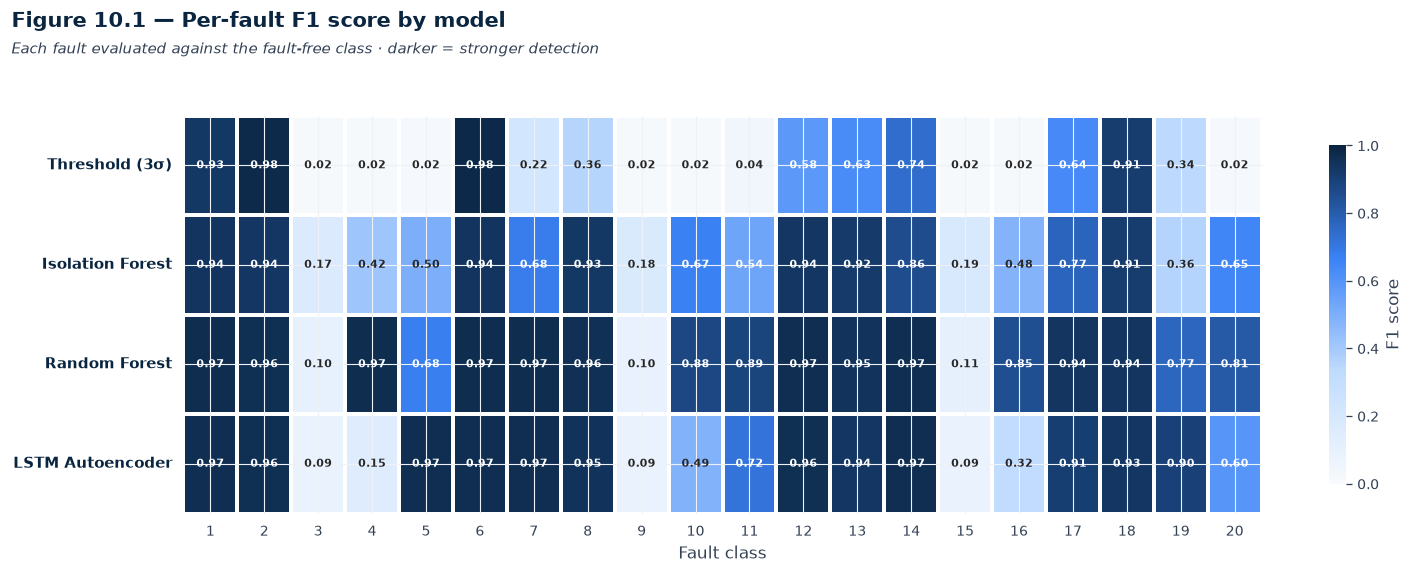

Hardest faults (mean F1 across models):
3     0.094
9     0.095
15    0.102
4     0.389
16    0.418


In [23]:
fig, ax = plt.subplots(figsize=(13.5, 4.6))
sns.heatmap(pf.T, annot=True, fmt=".2f", cmap=BLUES_SEQ, vmin=0, vmax=1,
            linewidths=1.4, linecolor="white", cbar_kws={"label":"F1 score","shrink":0.85},
            annot_kws={"fontsize":7.0,"fontweight":"bold"}, ax=ax)
ax.set_xlabel("Fault class"); ax.set_ylabel(""); ax.tick_params(left=False, bottom=False)
plt.setp(ax.get_yticklabels(), fontsize=9.5, fontweight="bold", color=NAVY)
style_fig(fig, "Figure 10.1 \u2014 Per-fault F1 score by model",
          "Each fault evaluated against the fault-free class \u00b7 darker = stronger detection")
plt.tight_layout(rect=[0,0,1,0.91]); save_show(fig, "f10_1_perfault")
print("Hardest faults (mean F1 across models):")
print(pf.mean(axis=1).nsmallest(5).round(3).to_string())

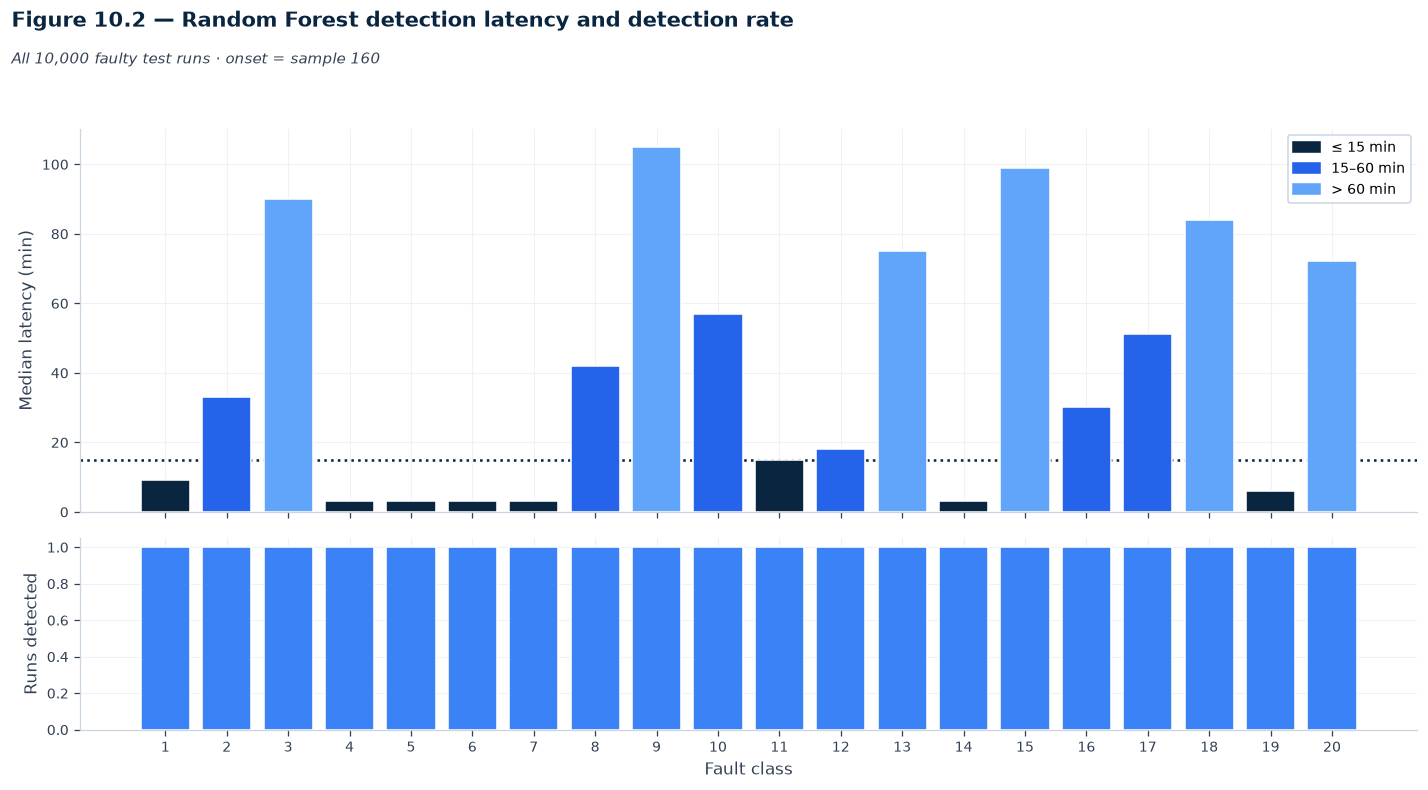

Median latency 21 min · 8/20 classes within 15 min · 0 runs never flagged


In [24]:
faulty_test = test[test.faultNumber > 0]
lat_rows, undetected = [], 0
for rk, g in faulty_test.groupby("runKey", sort=False):
    g = g.sort_values("sample")
    p = rf.predict(scaler.transform(g[FEATURES].values).astype("float32"))
    post = g["sample"].values > CFG.ONSET_TEST
    hit  = np.where(p.astype(bool) & post)[0]
    if len(hit):
        lat_rows.append({"fault": int(g["faultNumber"].iloc[0]),
                         "run": int(g["simulationRun"].iloc[0]),
                         "latency_min": int((g["sample"].values[hit[0]] - CFG.ONSET_TEST) * CFG.SAMPLE_MIN)})
    else:
        undetected += 1
lat = pd.DataFrame(lat_rows)
lat.to_csv(os.path.join(RESULTS_DIR, "detection_latency.csv"), index=False)
lat_mean = lat.groupby("fault")["latency_min"].median()
det_rate = lat.groupby("fault").size() / faulty_test.groupby("faultNumber")["runKey"].nunique()

fig, axes = plt.subplots(2, 1, figsize=(12.5, 6.4), sharex=True, gridspec_kw={"height_ratios":[2,1]})
def tier(v): return NAVY if v <= 15 else (ROYAL if v <= 60 else SKY)
axes[0].bar(lat_mean.index.astype(str), lat_mean.values,
            color=[tier(v) for v in lat_mean.values], edgecolor="white", zorder=3)
axes[0].axhline(15, color=NAVY, ls=":", lw=1.6)
axes[0].legend(handles=[Patch(color=NAVY, label="\u2264 15 min"), Patch(color=ROYAL, label="15\u201360 min"),
                        Patch(color=SKY, label="> 60 min")], fontsize=8.5)
axes[0].set_ylabel("Median latency (min)"); axes[0].set_axisbelow(True)
axes[1].bar(det_rate.index.astype(str), det_rate.values, color=STEEL, edgecolor="white", zorder=3)
axes[1].set_ylim(0, 1.05); axes[1].set_ylabel("Runs detected"); axes[1].set_xlabel("Fault class")
axes[1].set_axisbelow(True)
style_fig(fig, "Figure 10.2 \u2014 Random Forest detection latency and detection rate",
          f"All {faulty_test.runKey.nunique():,} faulty test runs \u00b7 onset = sample {CFG.ONSET_TEST}")
plt.tight_layout(rect=[0,0,1,0.93]); save_show(fig, "f10_2_latency")
print(f"Median latency {lat['latency_min'].median():.0f} min \u00b7 "
      f"{(lat_mean <= 15).sum()}/{len(lat_mean)} classes within 15 min \u00b7 "
      f"{undetected:,} runs never flagged")

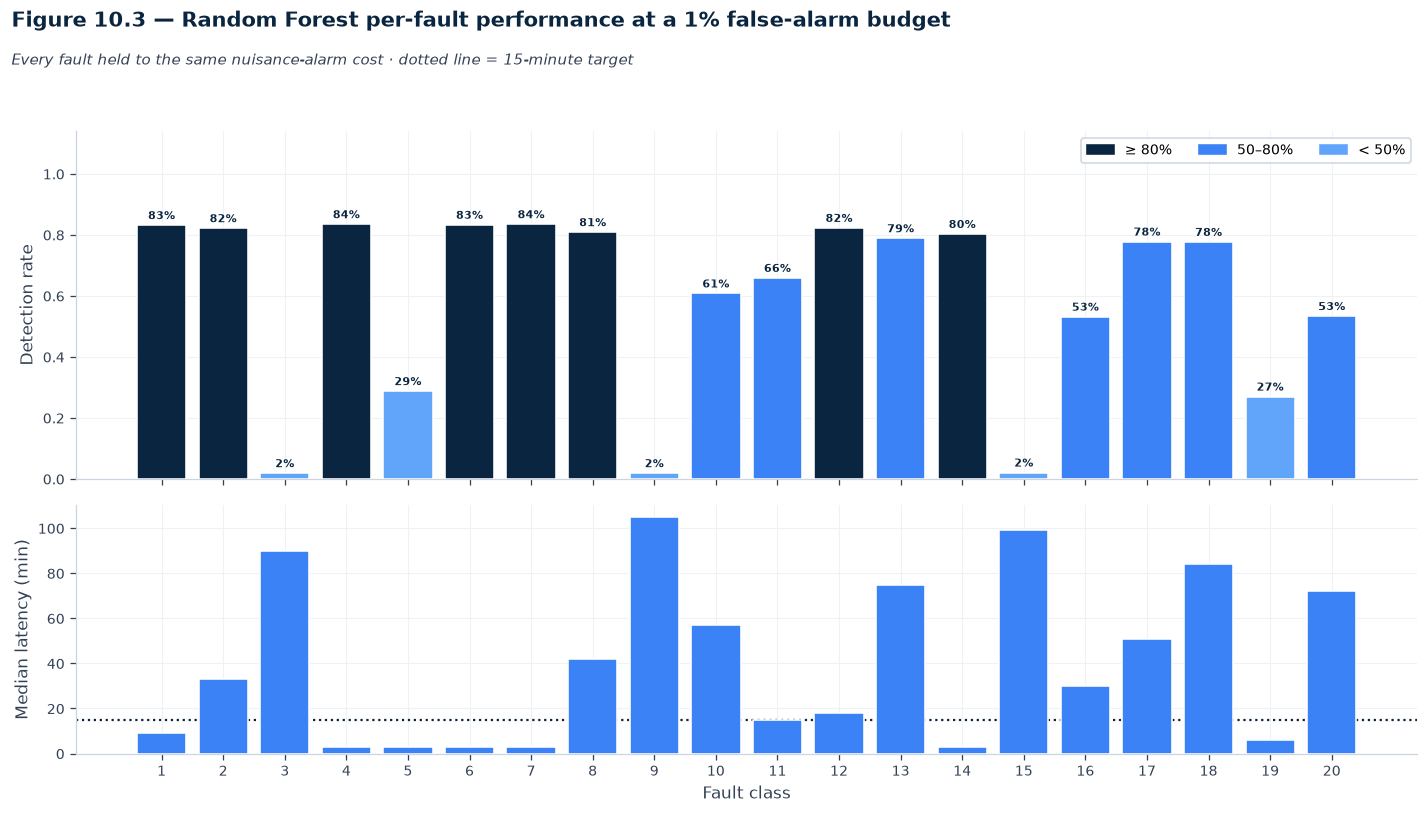

At a 1% false-alarm budget: 8/20 faults detected ≥80% of the time, 5/20 below 50%.


,Fault,Detection @ 1% FAR,Median latency (min)
0,1,0.832,9.0
1,2,0.822,33.0
2,3,0.019,90.0
3,4,0.835,3.0
4,5,0.288,3.0
5,6,0.833,3.0
6,7,0.835,3.0
7,8,0.809,42.0
8,9,0.019,105.0
9,10,0.608,57.0


In [25]:
# ── Per-fault performance at a matched 1% false-alarm budget ──
thr_1pct = np.quantile(rf_proba[y_te == 0], 0.99)
rows = []
for f in range(1, 21):
    m = f_te == f
    lat_f = lat.loc[lat.fault == f, "latency_min"]
    rows.append({"Fault": f,
                 "Detection @ 1% FAR": float((rf_proba[m] > thr_1pct).mean()),
                 "Median latency (min)": float(lat_f.median()) if len(lat_f) else np.nan})
per_fault_ops = pd.DataFrame(rows).round(3)
per_fault_ops.to_csv(os.path.join(RESULTS_DIR, "per_fault_operational.csv"), index=False)

fig, axes = plt.subplots(2, 1, figsize=(12.5, 6.6), sharex=True, gridspec_kw={"height_ratios":[1.4,1]})
d = per_fault_ops["Detection @ 1% FAR"]
cols_ = [NAVY if v >= 0.8 else (STEEL if v >= 0.5 else SKY) for v in d]
bars = axes[0].bar(per_fault_ops["Fault"].astype(str), d, color=cols_, edgecolor="white", zorder=3)
axes[0].bar_label(bars, labels=[f"{v:.0%}" for v in d], fontsize=7.2,
                  color=NAVY, fontweight="bold", padding=2)
axes[0].set_ylim(0, 1.14); axes[0].set_ylabel("Detection rate"); axes[0].set_axisbelow(True)
axes[0].legend(handles=[Patch(color=NAVY, label="\u2265 80%"), Patch(color=STEEL, label="50\u201380%"),
                        Patch(color=SKY, label="< 50%")], fontsize=8.5, ncol=3, loc="upper right")
axes[1].bar(per_fault_ops["Fault"].astype(str), per_fault_ops["Median latency (min)"],
            color=STEEL, edgecolor="white", zorder=3)
axes[1].axhline(15, color=NAVY, ls=":", lw=1.4)
axes[1].set_ylabel("Median latency (min)"); axes[1].set_xlabel("Fault class"); axes[1].set_axisbelow(True)
style_fig(fig, "Figure 10.3 \u2014 Random Forest per-fault performance at a 1% false-alarm budget",
          "Every fault held to the same nuisance-alarm cost \u00b7 dotted line = 15-minute target")
plt.tight_layout(rect=[0,0,1,0.93]); save_show(fig, "f10_3_perfault_ops")
print(f"At a 1% false-alarm budget: {(d>=0.8).sum()}/20 faults detected \u226580% of the time, "
      f"{(d<0.5).sum()}/20 below 50%.")
per_fault_ops

## 11 · Ablation — LSTM-AE Window Size

Each window length is trained with the same generous budget (60 epochs, early stopping patience 10)
so the comparison reflects the architecture rather than who ran out of epochs first.

  window=5 (15 min) …
  window=10 (30 min) …
  window=20 (60 min) …
  window=30 (90 min) …


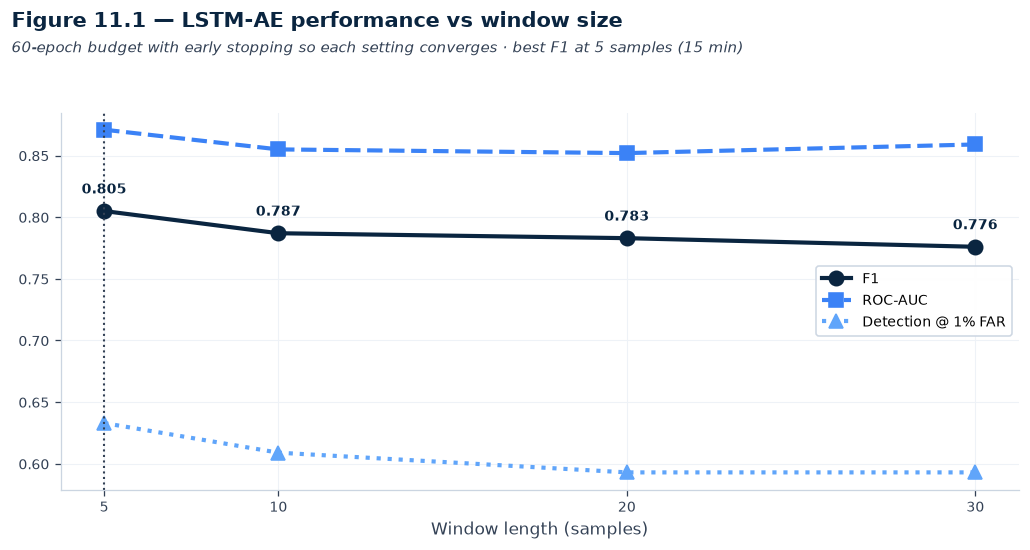

 Window  Minutes    F1  ROC-AUC  Det @ 1% FAR
      5       15 0.805    0.871         0.633
     10       30 0.787    0.855         0.609
     20       60 0.783    0.852         0.593
     30       90 0.776    0.859         0.593

Best window by F1: 5 samples. CFG.WINDOW is currently 10.
⚠ The ablation favours a different window than the one used in §8.
  Either set CFG.WINDOW = 5 and re-run §8, or justify the choice in the thesis.


In [26]:
ablation_rows = []
for w_size in CFG.ABL_WINDOWS:
    print(f"  window={w_size} ({w_size*CFG.SAMPLE_MIN} min) \u2026")
    Xa_fit = np.concatenate([b[0] for b in
                build_windows(ff_runs[ff_runs.runKey.isin(fit_runs_ae)], w_size)])
    Xa_val = np.concatenate([b[0] for b in
                build_windows(ff_runs[ff_runs.runKey.isin(val_runs_ae)], w_size)])
    ae = build_ae(w_size, len(FEATURES), CFG.LSTM_UNITS)
    ae.fit(Xa_fit, Xa_fit, validation_data=(Xa_val, Xa_val),
           epochs=CFG.ABL_EPOCHS, batch_size=CFG.LSTM_BATCH, verbose=0,
           callbacks=[callbacks.EarlyStopping(monitor="val_loss", patience=10,
                                              restore_best_weights=True),
                      callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                                                  patience=5, min_lr=1e-5)])
    e_val = np.mean((Xa_val - ae.predict(Xa_val, verbose=0))**2, axis=(1,2))
    thr = np.percentile(e_val, CFG.AE_PCTL)
    ys, es = [], []
    for Xw, yw, _ in build_windows(test, w_size):
        ys.append(yw); es.append(np.mean((Xw - ae.predict(Xw, verbose=0))**2, axis=(1,2)).astype("float32"))
        del Xw
    ys, es = np.concatenate(ys), np.concatenate(es)
    _, det1, _ = detection_at_far(ys, es, 0.01)
    ablation_rows.append({"Window": w_size, "Minutes": w_size*CFG.SAMPLE_MIN,
                          "F1": f1_score(ys, (es > thr).astype(int), zero_division=0),
                          "ROC-AUC": roc_auc_score(ys, es), "Det @ 1% FAR": float(det1)})
    del ae, Xa_fit, Xa_val, ys, es; gc.collect()

abl = pd.DataFrame(ablation_rows).round(3)
abl.to_csv(os.path.join(RESULTS_DIR, "ablation_window.csv"), index=False)

fig, ax = plt.subplots(figsize=(9, 4.4))
ax.plot(abl["Window"], abl["F1"], "o-", color=NAVY, lw=2.6, ms=9, label="F1")
ax.plot(abl["Window"], abl["ROC-AUC"], "s--", color=STEEL, lw=2.6, ms=9, label="ROC-AUC")
ax.plot(abl["Window"], abl["Det @ 1% FAR"], "^:", color=SKY, lw=2.6, ms=9, label="Detection @ 1% FAR")
for _, r in abl.iterrows():
    ax.annotate(f"{r['F1']:.3f}", (r["Window"], r["F1"]), textcoords="offset points",
                xytext=(0,11), fontsize=8.5, color=NAVY, fontweight="bold", ha="center")
best_w = int(abl.loc[abl["F1"].idxmax(), "Window"])
ax.axvline(best_w, color=SLATE, ls=":", lw=1.3)
ax.set_xticks(abl["Window"]); ax.set_xlabel("Window length (samples)")
ax.legend(fontsize=9); ax.set_axisbelow(True)
style_fig(fig, "Figure 11.1 \u2014 LSTM-AE performance vs window size",
          f"{CFG.ABL_EPOCHS}-epoch budget with early stopping so each setting converges "
          f"\u00b7 best F1 at {best_w} samples ({best_w*CFG.SAMPLE_MIN} min)")
plt.tight_layout(rect=[0,0,1,0.91]); save_show(fig, "f11_1_ablation")
print(abl.to_string(index=False))
print(f"\nBest window by F1: {best_w} samples. CFG.WINDOW is currently {CFG.WINDOW}.")
if best_w != CFG.WINDOW:
    print("\u26a0 The ablation favours a different window than the one used in \u00a78.")
    print("  Either set CFG.WINDOW = %d and re-run \u00a78, or justify the choice in the thesis." % best_w)

## 12 · SHAP Explainability *(RQ3)*

SHAP is O(n) in explained samples, so attributions are computed on a **stratified subset** of the
test set. This is a property of the explainability method, not of the models — the Random Forest
being explained was fitted on all 5.25 million training rows.

The per-fault map uses **driver lift** (a sensor's SHAP weight for one fault divided by its average
across all faults). Raw SHAP is dominated by two globally-important sensors, which would tell an
operator to check the same two things for every fault; lift surfaces what is *distinctive*.

In [27]:
rng = np.random.RandomState(CFG.SEED)
per_class = max(CFG.SHAP_SAMPLE // 21, 40)
idx = np.concatenate([rng.choice(np.where(f_te == c)[0],
                                 min(per_class, int((f_te == c).sum())), replace=False)
                      for c in range(0, 21)])
X_expl = scaler.transform(test[FEATURES].values[idx]).astype("float32")
y_expl, f_expl = y_te[idx], f_te[idx]

explainer = shap.TreeExplainer(rf)
sv_raw = explainer.shap_values(X_expl)
sv = sv_raw[1] if isinstance(sv_raw, list) else (sv_raw[:, :, 1] if sv_raw.ndim == 3 else sv_raw)
ev = explainer.expected_value
BASE = float(ev[1]) if hasattr(ev, "__len__") else float(ev)
print(f"SHAP matrix {sv.shape} \u00b7 base {BASE:.3f} \u00b7 "
      f"{len(idx):,} stratified test samples across 21 classes")

SHAP matrix (1995, 52) · base 0.500 · 1,995 stratified test samples across 21 classes


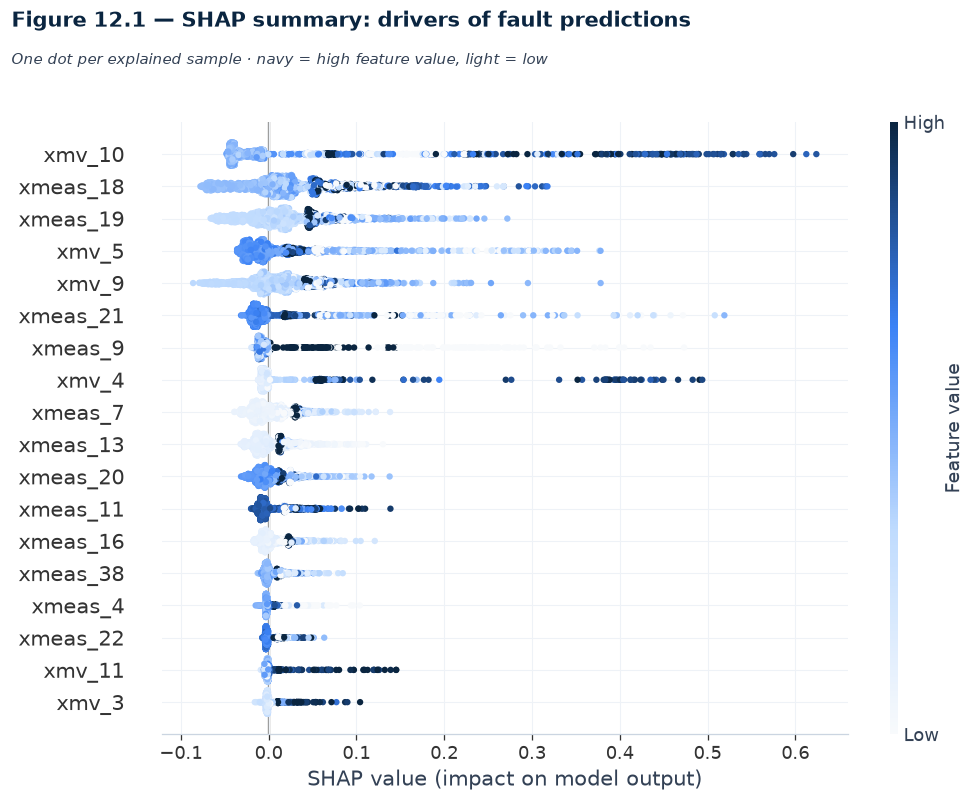

In [28]:
shap.summary_plot(sv, X_expl, feature_names=FEATURES, max_display=18,
                  show=False, cmap=BLUES_SEQ, plot_size=(9, 6.5))
fig = plt.gcf()
style_fig(fig, "Figure 12.1 \u2014 SHAP summary: drivers of fault predictions",
          "One dot per explained sample \u00b7 navy = high feature value, light = low")
plt.tight_layout(rect=[0,0,1,0.95]); save_show(fig, "f12_1_shap_summary")

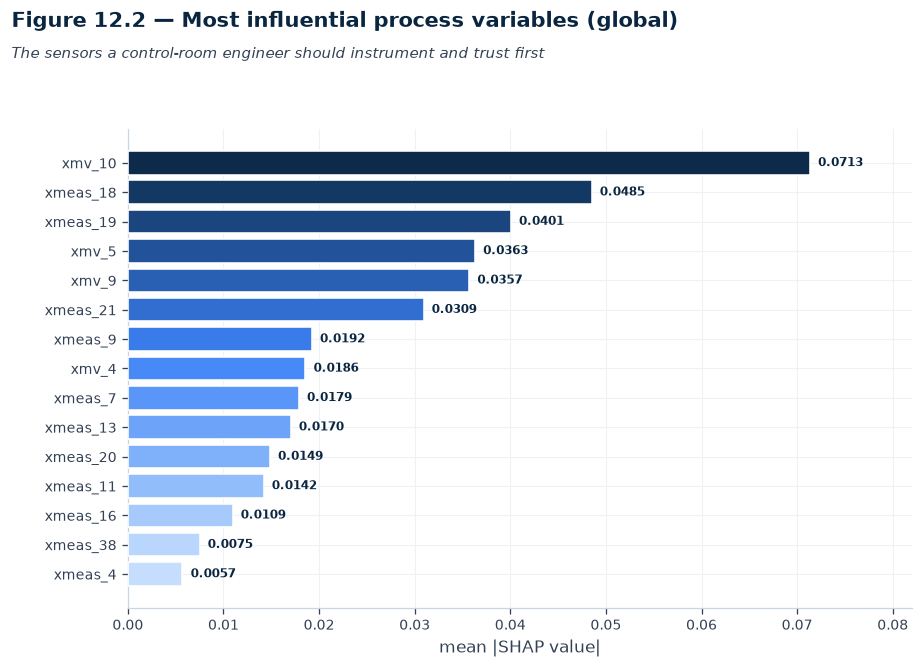

In [29]:
mean_abs = pd.Series(np.abs(sv).mean(axis=0), index=FEATURES).nlargest(15).sort_values()
fig, ax = plt.subplots(figsize=(8.8, 5.4))
grad = [BLUES_SEQ(0.30 + 0.68*i/(len(mean_abs)-1)) for i in range(len(mean_abs))]
ax.barh(mean_abs.index, mean_abs.values, color=grad, edgecolor="white", zorder=3)
for i, v in enumerate(mean_abs.values):
    ax.text(v + mean_abs.max()*0.012, i, f"{v:.4f}", va="center", fontsize=7.8,
            color=NAVY, fontweight="bold")
ax.set_xlabel("mean |SHAP value|"); ax.set_xlim(0, mean_abs.max()*1.15); ax.set_axisbelow(True)
style_fig(fig, "Figure 12.2 \u2014 Most influential process variables (global)",
          "The sensors a control-room engineer should instrument and trust first")
save_show(fig, "f12_2_shap_bar")

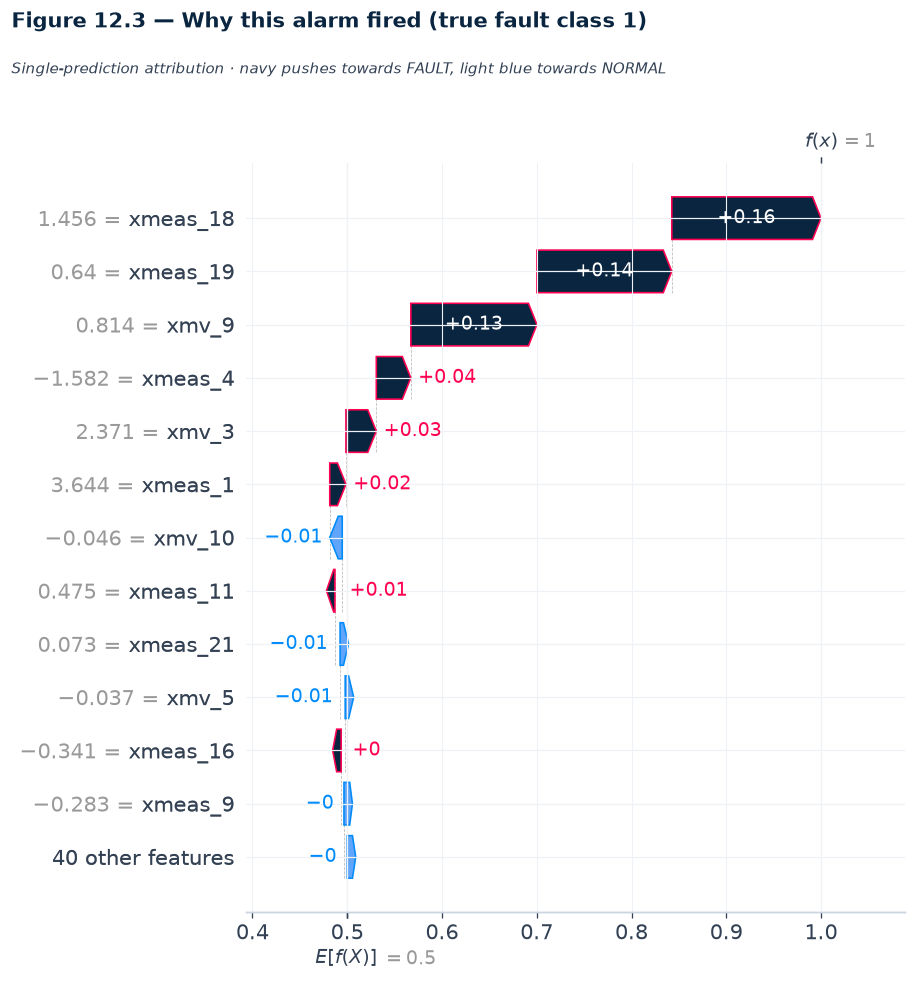

In [30]:
i = int(np.where(y_expl == 1)[0][0])
shap.plots.waterfall(shap.Explanation(values=sv[i], base_values=BASE,
                                      data=X_expl[i], feature_names=FEATURES),
                     max_display=13, show=False)
fig = navy_shap(plt.gcf())
style_fig(fig, f"Figure 12.3 \u2014 Why this alarm fired (true fault class {int(f_expl[i])})",
          "Single-prediction attribution \u00b7 navy pushes towards FAULT, light blue towards NORMAL")
plt.tight_layout(rect=[0,0,1,0.95]); save_show(fig, "f12_3_shap_waterfall")

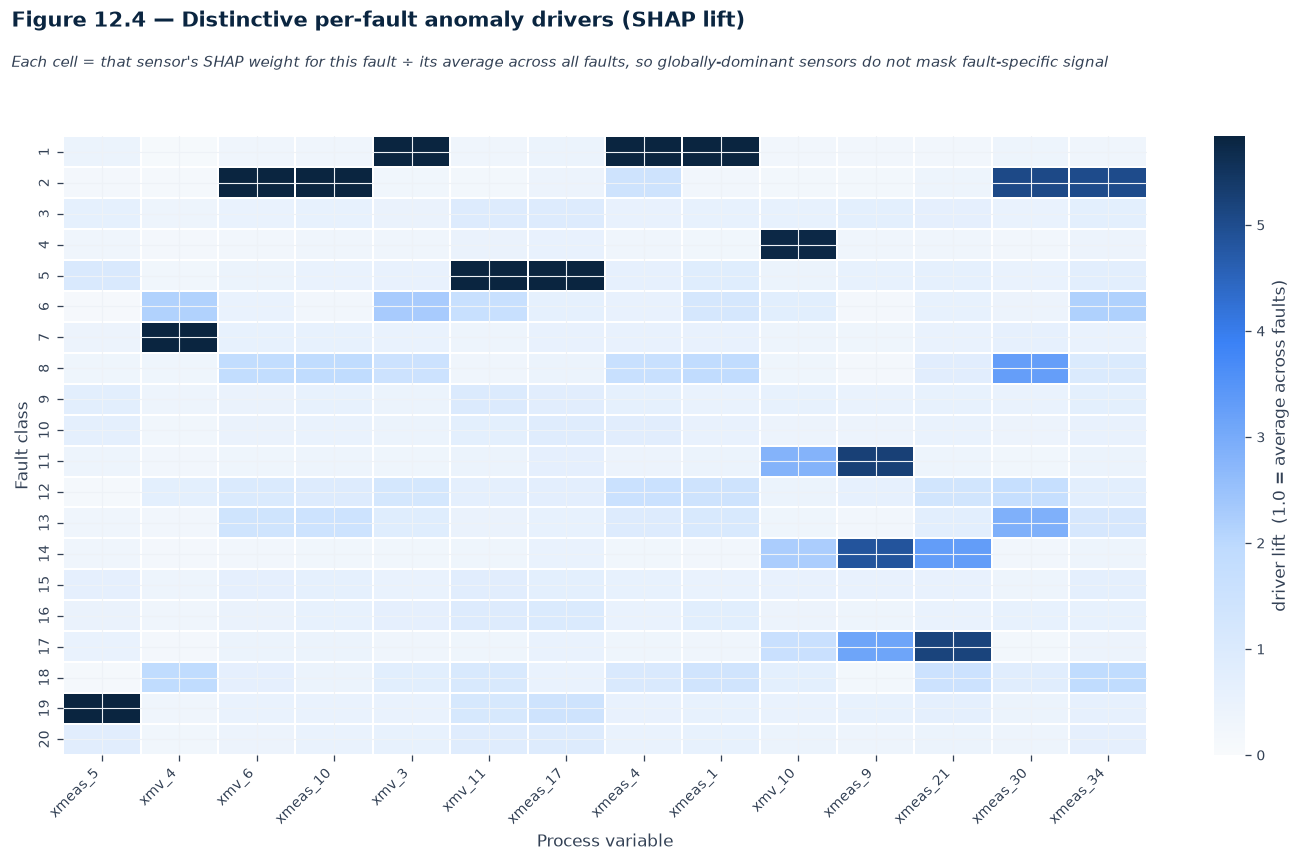

Distinctive top driver per fault class:
1        xmv_3
2        xmv_6
3      xmeas_2
4       xmv_10
5       xmv_11
6        xmv_3
7        xmv_4
8     xmeas_30
9     xmeas_37
10    xmeas_18
11     xmeas_9
12    xmeas_24
13    xmeas_30
14     xmeas_9
15    xmeas_40
16       xmv_9
17    xmeas_21
18       xmv_1
19     xmeas_5
20       xmv_5


In [31]:
# ── Alarm-rationalisation map using driver LIFT ──
rows = {}
for f in range(1, 21):
    m = f_expl == f
    if m.sum() >= 10:
        rows[f] = pd.Series(np.abs(sv[m]).mean(axis=0), index=FEATURES)
drv = pd.DataFrame(rows).T
lift = drv.div(drv.mean(axis=0) + 1e-12, axis=1)
top = lift.max(axis=0).nlargest(14).index

fig, ax = plt.subplots(figsize=(12.5, 7))
sns.heatmap(lift[top], cmap=BLUES_SEQ, vmin=0, vmax=float(np.percentile(lift[top].values, 97)),
            cbar_kws={"label":"driver lift  (1.0 = average across faults)"},
            linewidths=1.2, linecolor="white", ax=ax)
ax.set_xlabel("Process variable"); ax.set_ylabel("Fault class")
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
style_fig(fig, "Figure 12.4 \u2014 Distinctive per-fault anomaly drivers (SHAP lift)",
          "Each cell = that sensor's SHAP weight for this fault \u00f7 its average across all faults, "
          "so globally-dominant sensors do not mask fault-specific signal")
plt.tight_layout(rect=[0,0,1,0.93]); save_show(fig, "f12_4_shap_lift")
lift[top].round(2).to_csv(os.path.join(RESULTS_DIR, "shap_driver_lift.csv"))
print("Distinctive top driver per fault class:")
print(lift.idxmax(axis=1).to_string())

## 13 · Error Analysis

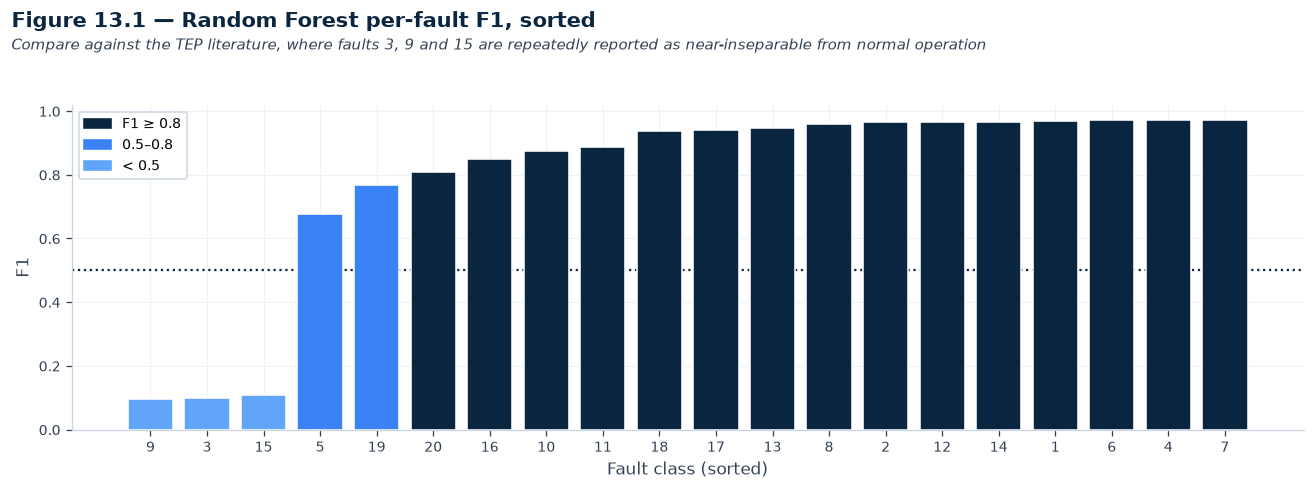

In [32]:
rf_pf = pf["Random Forest"].sort_values()
fig, ax = plt.subplots(figsize=(11.5, 3.9))
cols = [SKY if v < 0.5 else (STEEL if v < 0.8 else NAVY) for v in rf_pf.values]
ax.bar(rf_pf.index.astype(str), rf_pf.values, color=cols, edgecolor="white", zorder=3)
ax.axhline(0.5, color=NAVY, ls=":", lw=1.4)
ax.legend(handles=[Patch(color=NAVY, label="F1 \u2265 0.8"), Patch(color=STEEL, label="0.5\u20130.8"),
                   Patch(color=SKY, label="< 0.5")], fontsize=8.5)
ax.set_xlabel("Fault class (sorted)"); ax.set_ylabel("F1"); ax.set_axisbelow(True)
style_fig(fig, "Figure 13.1 \u2014 Random Forest per-fault F1, sorted",
          "Compare against the TEP literature, where faults 3, 9 and 15 are repeatedly reported "
          "as near-inseparable from normal operation")
plt.tight_layout(rect=[0,0,1,0.91]); save_show(fig, "f13_1_hardest")

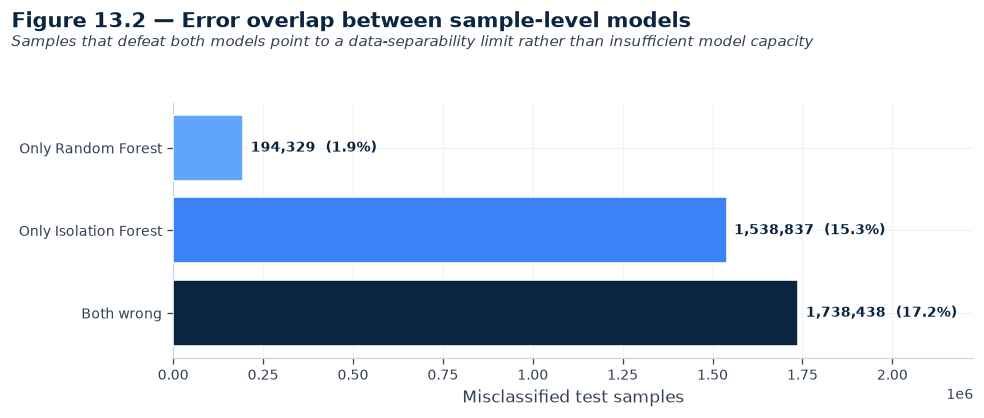

In [33]:
err_iso, err_rf = iso_pred != y_te, rf_pred != y_te
vals   = [int((err_iso & err_rf).sum()), int((err_iso & ~err_rf).sum()), int((~err_iso & err_rf).sum())]
labels = ["Both wrong", "Only Isolation Forest", "Only Random Forest"]
fig, ax = plt.subplots(figsize=(8.6, 3.3))
ax.barh(labels, vals, color=[NAVY, STEEL, SKY], edgecolor="white", zorder=3)
for i, v in enumerate(vals):
    ax.text(v + max(vals)*0.012, i, f"{v:,}  ({v/len(y_te):.1%})", va="center",
            fontsize=9, color=NAVY, fontweight="bold")
ax.set_xlim(0, max(vals)*1.28); ax.set_xlabel("Misclassified test samples"); ax.set_axisbelow(True)
style_fig(fig, "Figure 13.2 \u2014 Error overlap between sample-level models",
          "Samples that defeat both models point to a data-separability limit rather than "
          "insufficient model capacity")
plt.tight_layout(rect=[0,0,1,0.89]); save_show(fig, "f13_2_overlap")

## 14 · Leakage Audit & Conclusions

An explicit, verifiable audit that training and evaluation data are independent — the standard
objection to any time-series ML result, and the one raised in review of an earlier draft.

In [34]:
print("\u2550"*66); print("DATA-LEAKAGE AUDIT"); print("\u2550"*66)

print("\n1. Split protocol")
print("   Train  <- TEP_FaultFree_Training.csv + TEP_Faulty_Training.csv")
print("   Test   <- TEP_FaultFree_Testing.csv  + TEP_Faulty_Testing.csv")
print("   No random splitting is performed anywhere in this notebook.")

print("\n2. Exact duplicate rows between train and test (hashing ~15M rows, ~2 min)")
h_tr = pd.util.hash_pandas_object(train[FEATURES], index=False)
h_te = pd.util.hash_pandas_object(test[FEATURES],  index=False)
dupes = len(set(h_tr.values) & set(h_te.values))
print(f"   train {len(h_tr):,} rows | test {len(h_te):,} rows")
print(f"   shared rows: {dupes}  {'PASS' if dupes == 0 else 'FAIL'}")
del h_tr, h_te; gc.collect()

overlap_ae = len(set(fit_runs_ae) & set(val_runs_ae))
print("\n3. LSTM fit/validation separation")
print(f"   fit runs {len(fit_runs_ae)} | val runs {len(val_runs_ae)} | overlap {overlap_ae}  "
      f"{'PASS' if overlap_ae == 0 else 'FAIL'}")

print("\n4. Window integrity")
print("   Windows are built from consecutive samples within a single simulation run and")
print("   sorted by `sample`; windows spanning the fault-injection point are discarded.")

print("\n5. Scaler fitting")
print(f"   StandardScaler fitted on {len(train):,} training rows only.")
print("\n" + "\u2550"*66)

audit = pd.DataFrame([
    {"Check": "Random train/test splitting used",   "Result": "No"},
    {"Check": "Exact rows shared train<->test",     "Result": str(dupes)},
    {"Check": "LSTM fit/val run overlap",           "Result": str(overlap_ae)},
    {"Check": "Windows cross run boundaries",       "Result": "No"},
    {"Check": "Scaler fitted on test data",         "Result": "No"},
])
audit.to_csv(os.path.join(RESULTS_DIR, "leakage_audit.csv"), index=False)
audit

══════════════════════════════════════════════════════════════════
DATA-LEAKAGE AUDIT
══════════════════════════════════════════════════════════════════

1. Split protocol
   Train  <- TEP_FaultFree_Training.csv + TEP_Faulty_Training.csv
   Test   <- TEP_FaultFree_Testing.csv  + TEP_Faulty_Testing.csv
   No random splitting is performed anywhere in this notebook.

2. Exact duplicate rows between train and test (hashing ~15M rows, ~2 min)
   train 5,250,000 rows | test 10,080,000 rows
   shared rows: 0  PASS

3. LSTM fit/validation separation
   fit runs 450 | val runs 50 | overlap 0  PASS

4. Window integrity
   Windows are built from consecutive samples within a single simulation run and
   sorted by `sample`; windows spanning the fault-injection point are discarded.

5. Scaler fitting
   StandardScaler fitted on 5,250,000 training rows only.

══════════════════════════════════════════════════════════════════


,Check,Result
0,Random train/test splitting used,No
1,Exact rows shared train<->test,0
2,LSTM fit/val run overlap,0
3,Windows cross run boundaries,No
4,Scaler fitted on test data,No


In [35]:
print("\u2550"*72); print("FINAL RESULTS \u2014 official TEP test files, no sampling"); print("\u2550"*72)
print("\nClassical metrics:"); print(results.to_string())
print("\nOperational metrics:"); print(ops.to_string())
print("\nDetection at matched false-alarm budgets:"); print(far_tbl.to_string())
print("\nPaired significance tests:"); print(stat_df.to_string(index=False))
print(f"\nTrain rows: {len(train):,}  (normal {int((y_tr==0).sum()):,} / fault {int((y_tr==1).sum()):,})")
print(f"Test  rows: {len(test):,}  (normal {int((y_te==0).sum()):,} / fault {int((y_te==1).sum()):,})")
print(f"\nProject folder: {os.path.abspath(BASE_DIR)}/")
for d, n in [("figures", FIG_DIR), ("results", RESULTS_DIR), ("models", MODELS_DIR)]:
    print(f"  {d}/ \u2192 {len(os.listdir(n))} file(s)")

════════════════════════════════════════════════════════════════════════
FINAL RESULTS — official TEP test files, no sampling
════════════════════════════════════════════════════════════════════════

Classical metrics:
                         Paradigm  Train time (s)  Precision  Recall     F1  ROC-AUC  Bal. Acc.
Threshold (3σ)         Rule-based               0      0.992   0.314  0.478    0.720      0.652
Isolation Forest     Unsupervised               3      0.977   0.605  0.747    0.864      0.775
Random Forest          Supervised             886      0.990   0.766  0.864    0.919      0.869
LSTM Autoencoder  Semi-supervised             361      0.983   0.670  0.797    0.860      0.813

Operational metrics:
                  Detection rate  False-alarm rate  Miss rate     MCC  ROC-AUC
Threshold (3σ)            0.3145            0.0096     0.6855  0.2843   0.7197
Isolation Forest          0.6048            0.0556     0.3952  0.4445   0.8645
Random Forest             0.7659          

### Answers to the research questions

| RQ | Where to read the answer |
|---|---|
| **RQ1** — can ML beat conventional threshold alarms? | Figure 9.4 compares every detector at an identical false-alarm budget; Figure 9.5 shows the same in curve form; Figure 10.2 gives detection latency. The Wilcoxon rows involving *Threshold (3σ)* establish significance. |
| **RQ2** — which model gives the best accuracy / false-alarm trade-off? | Figure 9.3 and Figure 9.4 for the operating point, Figure 9.1 for classical metrics, `results/wilcoxon_tests.csv` to confirm the margin is not sampling noise, Figure 10.1 for per-fault behaviour. |
| **RQ3** — can explainability make detections actionable? | Figure 12.4 converts each fault class into a ranked sensor checklist; Figure 12.3 shows the same attribution for one individual alarm. |

### Limitations

- TEP is a **simulation**. Real historian data is noisier, less balanced and far more sparsely labelled, so these scores should be read as an upper bound on real-plant performance.
- Faults **3, 9 and 15** are widely reported in the TEP literature as producing deviations statistically indistinguishable from normal operation. Weak scores there reflect the data, not the implementation (§13).
- The LSTM Autoencoder is scored **per 30-minute window** while the tree models are scored **per sample**; the two are not numerically interchangeable, and window-level scores are more forgiving of a single anomalous reading.
- **Transition windows** straddling the injection point are excluded from the autoencoder evaluation, so it is never scored on the exact moment of onset. Detection latency is therefore measured on the Random Forest.
- SHAP attributions use a stratified subset of the test set because the method is O(n) in explained samples; the model being explained was fitted and evaluated on the complete data.

*Full dataset · onset-aware labelling · canonical train/test protocol · run-level validation · navy/blue design system · every figure numbered and saved at 150 dpi · seed 42.*